<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/04_construction_review_indicators_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DADS5001 Mini Project
## การพัฒนาตัวชี้วัดเพื่อการตรวจสอบโครงการจ้างก่อสร้าง ปีงบประมาณ 2569

Notebook 03 พบเบาะแสสำคัญสามด้าน ได้แก่ ค่าราคาที่ห่างจากกรอบ
การกระจุกตัวของโครงการเฉพาะเจาะจงใกล้ 500,000 บาท และการกระจุกตัว
ของผู้รับจ้างบางรายภายในหน่วยงานย่อย Notebook นี้เปลี่ยนเบาะแสเหล่านั้น
เป็นเกณฑ์ที่ตรวจสอบซ้ำได้ เพื่อจัดลำดับโครงการที่ควรเปิดเอกสารก่อน

### เส้นทางจาก EDA สู่ตัวชี้วัด

| ข้อค้นพบจาก EDA | คำถามที่ตามมา | ตัวชี้วัด |
|---|---|---|
| พบราคาตกลงบางรายการสูงกว่ากรอบราคา | ส่วนต่างมีนัยสำคัญทั้งจำนวนเงินและร้อยละหรือไม่ | ส่วนต่างราคาอย่างมีสาระสำคัญ |
| พบโครงการเฉพาะเจาะจงจำนวนมากใกล้ 500,000 บาท | รูปแบบเดียวกันเกิดซ้ำภายใต้หน่วยงานและผู้รับจ้างเดียวกันหรือไม่ | รูปแบบใกล้ 500,000 บาทที่เกิดซ้ำ |
| มูลค่าระดับประเทศกระจุกในผู้รับจ้างบางส่วน | ภายในหน่วยงานย่อยมีผู้รับจ้างรายใดครองทั้งจำนวนและมูลค่าสูงหรือไม่ | การกระจุกตัวสูงของผู้รับจ้าง |

การวิเคราะห์แยกเป็นสองกลุ่ม:

1. **ตัวชี้วัดคุณภาพข้อมูล** ใช้ติดตามราคากลางสูญหาย
   สัดส่วนราคาผิดสังเกต และยอด Supplier Entity ที่ยังไม่ตรงกัน
2. **ตัวชี้วัดด้านการจัดซื้อจัดจ้าง** ใช้จัดลำดับโครงการจากรูปแบบ
   ราคา การเกิดซ้ำ และความกระจุกตัว

ปัญหาคุณภาพข้อมูลไม่ถูกนำไปเพิ่มระดับความสำคัญด้านการจัดซื้อ
เพื่อไม่ให้ความผิดพลาดของข้อมูลถูกตีความเป็นความเสี่ยงของโครงการ

> ตัวชี้วัดเป็นเครื่องมือคัดกรอง ไม่ใช่คะแนนการทุจริต
> และไม่ใช่ข้อสรุปว่าหน่วยงานหรือผู้รับจ้างกระทำผิด


In [14]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option(
    'display.float_format',
    lambda value: f'{value:,.2f}'
)

sns.set_theme(style='whitegrid')

processed_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/processed'
)

project_path = processed_dir / 'construction_projects_2569.csv'
contract_path = processed_dir / 'construction_contracts_2569.csv'
supplier_path = processed_dir / 'construction_supplier_summary_2569.csv'

In [17]:
project_directory = processed_dir.parents[3]
figure_directory = (
    project_directory
    / 'dads5001-data-tools'
    / 'project'
    / 'eda'
    / 'figure'
)
figure_directory.mkdir(parents=True, exist_ok=True)

project_data = pd.read_csv(
    project_path,
    low_memory=False
)
contract_data = pd.read_csv(
    contract_path,
    low_memory=False
)
supplier_data = pd.read_csv(
    supplier_path,
    low_memory=False
)

assert len(project_data) == 178_978
assert len(contract_data) == 180_079
assert len(supplier_data) == 33_570

print(f'Figure directory: {figure_directory}')

print(f'Project data: {project_data.shape}')
print(f'Contract data: {contract_data.shape}')
print(f'Supplier data: {supplier_data.shape}')
print('Input validation passed')

Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dads5001-data-tools/project/eda/figure
Project data: (178978, 36)
Contract data: (180079, 29)
Supplier data: (33570, 8)
Input validation passed


## 1. กรอบการวิเคราะห์ตัวชี้วัด

การวิเคราะห์ดำเนินตามลำดับดังนี้:

1. ตรวจผลรวมมูลค่าระดับโครงการและระดับสัญญา
2. แยกแถวสมาชิกกิจการร่วมค้าออกจาก Supplier Entity
3. ตรวจยอดที่ยังไม่ตรงกันหลังปรับหน่วยวิเคราะห์
4. ตรวจราคากลางที่สูญหายหรือมีสัดส่วนผิดสังเกต
5. สร้างตัวชี้วัดด้านการจัดซื้อจัดจ้าง 3 มิติ
6. ตรวจการซ้อนทับและกำหนดลำดับความสำคัญ
7. เลือกกรณีศึกษาสำหรับการตรวจเอกสารเพิ่มเติม

แต่ละเงื่อนไขมีเหตุผล เกณฑ์ จำนวนโครงการ ตัวอย่างรายการ
และข้อจำกัดในการตีความ

In [18]:
# Column names used throughout this notebook
project_id_column = 'รหัสโครงการ'
project_name_column = 'ชื่อโครงการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
province_column = 'จังหวัด'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
budget_column = 'วงเงินงบประมาณ (บาท)'
reference_price_column = 'ราคากลาง (บาท)'
awarded_price_column = 'ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
contract_number_column = 'เลขที่สัญญา'
contract_budget_column = 'วงเงินงบประมาณในสัญญา (บาท)'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
subagency_column = 'ชื่อหน่วยงานย่อย'
announcement_date_column = 'วันที่ประกาศจัดซื้อจัดจ้าง'
transaction_date_column = 'วันที่เกิดรายการ'

## 2. ตัวชี้วัดคุณภาพข้อมูล

### 2.1 การตรวจยอดและโครงสร้างกิจการร่วมค้า

เริ่มจากเปรียบเทียบผลรวม `วงเงินงบประมาณในสัญญา (บาท)`
ของแต่ละโครงการกับ `ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญา
ในโครงการ (บาท)`

ความคลาดเคลื่อนในขั้นแรกยังไม่ถูกจัดเป็นปัญหาคุณภาพข้อมูลทันที
เพราะอาจเกิดจากการบันทึกทั้งแถว Consortium และแถวสมาชิก
กิจการร่วมค้า จึงต้องตรวจโครงสร้างข้อมูลก่อน

กำหนดค่าคลาดเคลื่อนที่ยอมรับได้ไม่เกิน 1 บาท
เพื่อรองรับผลจากการปัดเศษ

In [19]:
contract_value_by_project = (
    contract_data
    .groupby(project_id_column)[contract_budget_column]
    .sum(min_count=1)
    .rename('contract_budget_sum')
    .reset_index()
)

project_data = (project_data.merge(contract_value_by_project, on=project_id_column, how='left'))

project_data['contract_value_difference'] = (project_data['contract_budget_sum'] - project_data[awarded_price_column])
project_data['contract_value_abs_difference'] = (project_data['contract_value_difference'].abs())
project_data['contract_value_difference_pct'] = (project_data['contract_value_difference'].div(project_data[awarded_price_column]).mul(100))
project_data['flag_contract_mismatch'] = ~np.isclose(project_data['contract_budget_sum'], project_data[awarded_price_column], rtol=0, atol=1, equal_nan=False)

In [20]:
contract_mismatch_summary = pd.Series({
    'Total projects': (
        len(project_data)
    ),
    'Matched projects': (
        (~project_data[
            'flag_contract_mismatch'
        ]).sum()
    ),
    'Mismatch projects': (
        project_data[
            'flag_contract_mismatch'
        ].sum()
    ),
    'Mismatch pct': (
        project_data[
            'flag_contract_mismatch'
        ].mean()
        * 100
    ),
    'Total absolute difference': (
        project_data.loc[
            project_data[
                'flag_contract_mismatch'
            ],
            'contract_value_abs_difference'
        ].sum()
    )
})

display(
    contract_mismatch_summary
    .to_frame(name='value')
)

contract_mismatch_cases = (
    project_data
    .loc[
        project_data[
            'flag_contract_mismatch'
        ],
        [
            project_id_column,
            'ชื่อโครงการจัดซื้อจัดจ้าง',
            'ชื่อหน่วยงาน',
            method_column,
            awarded_price_column,
            'contract_budget_sum',
            'contract_value_difference',
            'contract_value_abs_difference',
            'contract_value_difference_pct'
        ]
    ]
    .sort_values(
        'contract_value_abs_difference',
        ascending=False
    )
)

display(
    contract_mismatch_cases.head(15)
)

,value
Total projects,"178,978.00"
Matched projects,"178,616.00"
Mismatch projects,362.00
Mismatch pct,0.20
Total absolute difference,"13,234,946,092.98"


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),contract_budget_sum,contract_value_difference,contract_value_abs_difference,contract_value_difference_pct
8,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"1,813,300,000.00","3,626,600,000.00","1,813,300,000.00","1,813,300,000.00",100.00
13,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),กรมทางหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"1,299,500,000.00","2,599,000,000.00","1,299,500,000.00","1,299,500,000.00",100.00
11,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปกรณ์ โครงการพัฒนาน้ำบาดาลเพื่อความมั่นคงระดับชุมชน จำนวน ๓๐๗ แห่ง งบประ...,กรมทรัพยากรน้ำบาดาล,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"1,663,819,967.00","2,304,873,377.00","641,053,410.00","641,053,410.00",38.53
87,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลังงานแสงอาทิตย์แบบผิวดิน พร้อมครุภัณฑ์ประกอบระบบกระจายน้ำพลังงานแสงอาทิต...,กรมการข้าว,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"408,500,000.00","817,000,000.00","408,500,000.00","408,500,000.00",100.00
136,68069048414,ประกวดราคาจ้างก่อสร้างพัฒนาระบบไมโครกริด ที่ อำเภอเมือง จังหวัดแม่ฮ่องสอน และปรับปรุงประสิทธิภาพระบบควบคุมและป้องกัน...,การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"249,500,000.00","499,000,000.00","249,500,000.00","249,500,000.00",100.00
140,68129397164,ประกวดราคาจ้างก่อสร้างงานก่อสร้างและเพิ่มประสิทธิภาพระบบบำบัดน้ำเสีย เทศบาลนครอุดรธานี ตำบลหมากแข้ง อำเภอเมืองอุดรธา...,องค์การจัดการน้ำเสีย,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"248,562,100.00","497,124,200.00","248,562,100.00","248,562,100.00",100.00
150,69029010512,ประกวดราคาจ้างก่อสร้างก่อสร้างอาคารทันตกรรมเพื่อผู้สูงอายุและผู้ป่วยความต้องการพิเศษ คณะทันตแพทยศาสตร์ มหาวิทยาลัยเช...,มหาวิทยาลัยเชียงใหม่,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"242,800,000.00","485,600,000.00","242,800,000.00","242,800,000.00",100.00
155,68059551063,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างระบบระบายน้ำคลองลาดเป็ด ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"234,400,000.00","468,800,000.00","234,400,000.00","234,400,000.00",100.00
159,67019030895,ประกวดราคาจ้างก่อสร้างรายการที่ 19. งานจ้างตกแต่งภายในระบบประกอบอาคารและงานภูมิสถาปัตยกรรม อาคารศูนย์บริการทางการแพท...,มหาวิทยาลัยเชียงใหม่,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"224,900,000.00","449,800,000.00","224,900,000.00","224,900,000.00",100.00
188,69136000003,ประกวดราคาจ้างก่อสร้างปรับปรุงระบบจำหน่ายไฟฟ้าเป็นเคเบิลใต้ดินบริเวณถนนไตรรัตน์ ถนนสนามบิน ถนนบรรพปราการ และถนนอุตรก...,การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"197,412,787.67","394,825,575.34","197,412,787.67","197,412,787.67",100.00


In [21]:
sample_mismatch_ids = (
    contract_mismatch_cases
    .head(5)[
        project_id_column
    ]
    .tolist()
)

sample_mismatch_rows = (
    contract_data
    .loc[
        contract_data[
            project_id_column
        ].isin(
            sample_mismatch_ids
        ),
        [
            project_id_column,
            'ชื่อโครงการจัดซื้อจัดจ้าง',
            supplier_id_column,
            supplier_name_column,
            'เลขที่สัญญา',
            contract_budget_column
        ]
    ]
    .sort_values(
        [
            project_id_column,
            'เลขที่สัญญา',
            supplier_id_column
        ]
    )
    .head(30)
)

display(sample_mismatch_rows)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท)
9,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,0105551101940,บริษัทจำกัด บริษัท อินเตอร์ลิ้งค์ เพาเวอร์ แอนด์ เอ็นจิเนียริ่ง จำกัด(สัญญากิจการค้าร่วม),จ.ป.105/2569,"798,214,660.00"
10,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,0107547000222,บริษัทมหาชนจำกัด บริษัท อินเตอร์ลิ้งค์ คอมมิวนิเคชั่น จำกัด (มหาชน)(สัญญากิจการค้าร่วม),จ.ป.105/2569,"936,750,780.00"
11,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,0107558000211,บริษัทมหาชนจำกัด บริษัท อินเตอร์ลิ้งค์ เทเลคอม จำกัด (มหาชน)(สัญญากิจการค้าร่วม),จ.ป.105/2569,"78,334,560.00"
8,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,D888888888001,INTERLINK CONSORTIUM,จ.ป.105/2569,"1,813,300,000.00"
29,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),0105539089307,บริษัทจำกัด บริษัท ธาราวัญ คอนสตรัคชั่น จำกัด(สัญญากิจการค้าร่วม),สท.1/7/2569,"670,542,000.00"
30,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),0535560000111,บริษัทจำกัด บริษัท ชอกมลรัตน์ จำกัด(สัญญากิจการค้าร่วม),สท.1/7/2569,"616,222,900.00"
31,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),0535561000107,บริษัทจำกัด บริษัท สุนิสาจุฬารัตน์การโยธา จำกัด(สัญญากิจการค้าร่วม),สท.1/7/2569,"12,735,100.00"
28,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),D888868004228,กิจการค้าร่วม บริษัท ธาราวัญ คอนสตรัคชั่น จำกัด และ บริษัท ชอกมลรัตน์ จำกัด และ บริษัท สุนิสาจุฬารัตน์การโยธา จำกัด,สท.1/7/2569,"1,299,500,000.00"
114,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลังงานแสงอาทิตย์แบบผิวดิน พร้อมครุภัณฑ์ประกอบระบบกระจายน้ำพลังงานแสงอาทิต...,0105560074186,บริษัทจำกัด บริษัท เอนเนอร์จี ฟอร์ ออลล์ จำกัด(สัญญากิจการค้าร่วม),สบก.สจ7/69,"139,029,050.31"
115,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลังงานแสงอาทิตย์แบบผิวดิน พร้อมครุภัณฑ์ประกอบระบบกระจายน้ำพลังงานแสงอาทิต...,0105563098639,บริษัทจำกัด บริษัท เกรท เซิร์ฟ จำกัด(สัญญากิจการค้าร่วม),สบก.สจ7/69,"103,617,906.42"


In [22]:
mismatch_project_profile = (
    contract_data
    .loc[
        contract_data[
            project_id_column
        ].isin(
            contract_mismatch_cases[
                project_id_column
            ]
        )
    ]
    .groupby(project_id_column)
    .agg(
        row_count=(
            project_id_column,
            'size'
        ),
        supplier_count=(
            supplier_id_column,
            'nunique'
        ),
        contract_number_count=(
            'เลขที่สัญญา',
            'nunique'
        ),
        contract_budget_value_count=(
            contract_budget_column,
            'nunique'
        )
    )
    .reset_index()
)

display(
    mismatch_project_profile
    .describe()
    .T
)

print(
    'Mismatch projects with multiple suppliers:',
    mismatch_project_profile[
        'supplier_count'
    ].gt(1).sum()
)

print(
    'Mismatch projects with multiple rows:',
    mismatch_project_profile[
        'row_count'
    ].gt(1).sum()
)

,count,mean,std,min,25%,50%,75%,max
รหัสโครงการ,362.00,"68,391,043,493.09","482,377,335.93","65,117,038,133.00","68,109,281,445.25","68,119,322,263.00","69,019,440,810.25","69,136,000,003.00"
row_count,362.00,3.02,0.82,2.00,3.00,3.00,3.00,13.00
supplier_count,362.00,3.02,0.76,2.00,3.00,3.00,3.00,13.00
contract_number_count,362.00,1.06,0.69,1.00,1.00,1.00,1.00,11.00
contract_budget_value_count,362.00,2.48,1.22,1.00,1.00,3.00,3.00,13.00


Mismatch projects with multiple suppliers: 362
Mismatch projects with multiple rows: 362


### การตีความส่วนต่างของมูลค่าระดับสัญญา

การตรวจสอบรายการจริงพบว่าโครงการที่ผลรวมวงเงินระดับสัญญา
สูงกว่าราคาตกลงระดับโครงการส่วนใหญ่เป็นสัญญากิจการร่วมค้า

ข้อมูลบันทึกทั้ง:

1. แถวของกิจการร่วมค้าหรือ Consortium ซึ่งมีวงเงินเต็มสัญญา
2. แถวของสมาชิกกิจการร่วมค้า ซึ่งมีวงเงินตามส่วนแบ่งของสมาชิก

หากรวมทุกแถวพร้อมกัน มูลค่าจะถูกนับทั้งระดับ Consortium
และระดับสมาชิก ทำให้ยอดรวมสูงกว่าราคาที่ตกลงระดับโครงการ

ดังนั้น ส่วนต่างดิบ 362 โครงการไม่ถือเป็นปัญหาคุณภาพข้อมูล
โดยอัตโนมัติ แต่สะท้อนว่าต้องกำหนดหน่วยวิเคราะห์ให้เหมาะสม

การวิเคราะห์ Supplier Entity จะเก็บแถว Consortium
และตัดแถวที่ระบุว่า `สัญญากิจการค้าร่วม`
เพื่อหลีกเลี่ยงการนับมูลค่าซ้ำ

In [23]:
contract_data[
    'is_joint_venture_member'
] = (
    contract_data[
        supplier_name_column
    ]
    .astype('string')
    .str.contains(
        'สัญญากิจการค้าร่วม',
        na=False
    )
)

joint_venture_member_summary = pd.Series({
    'Joint-venture member rows': (
        contract_data[
            'is_joint_venture_member'
        ].sum()
    ),
    'Projects with member rows': (
        contract_data.loc[
            contract_data[
                'is_joint_venture_member'
            ],
            project_id_column
        ].nunique()
    ),
    'Member-row contract value': (
        contract_data.loc[
            contract_data[
                'is_joint_venture_member'
            ],
            contract_budget_column
        ].sum()
    )
})

display(
    joint_venture_member_summary
    .to_frame(name='value')
)

,value
Joint-venture member rows,710.00
Projects with member rows,362.00
Member-row contract value,"13,056,748,297.50"


In [24]:
supplier_entity_data = (
    contract_data
    .loc[
        ~contract_data[
            'is_joint_venture_member'
        ]
    ]
    .copy()
)

entity_value_by_project = (
    supplier_entity_data
    .groupby(project_id_column)
    [contract_budget_column]
    .sum(
        min_count=1
    )
    .rename('entity_contract_value_sum')
    .reset_index()
)

entity_reconciliation = (
    project_data
    [
        [
            project_id_column,
            awarded_price_column
        ]
    ]
    .merge(
        entity_value_by_project,
        on=project_id_column,
        how='left'
    )
)

entity_reconciliation[
    'difference'
] = (
    entity_reconciliation[
        'entity_contract_value_sum'
    ]
    - entity_reconciliation[
        awarded_price_column
    ]
)

entity_reconciliation[
    'is_matched'
] = np.isclose(
    entity_reconciliation[
        'entity_contract_value_sum'
    ],
    entity_reconciliation[
        awarded_price_column
    ],
    rtol=0,
    atol=1,
    equal_nan=False
)

entity_reconciliation_summary = pd.Series({
    'Supplier entity rows': (
        len(supplier_entity_data)
    ),
    'Projects checked': (
        len(entity_reconciliation)
    ),
    'Matched projects': (
        entity_reconciliation[
            'is_matched'
        ].sum()
    ),
    'Unmatched projects': (
        ~entity_reconciliation[
            'is_matched'
        ]
    ).sum(),
    'Matched pct': (
        entity_reconciliation[
            'is_matched'
        ].mean()
        * 100
    ),
    'Total absolute difference': (
        entity_reconciliation[
            'difference'
        ].abs().sum()
    )
})

display(
    entity_reconciliation_summary
    .to_frame(name='value')
)

,value
Supplier entity rows,"179,369.00"
Projects checked,"178,978.00"
Matched projects,"178,967.00"
Unmatched projects,11.00
Matched pct,99.99
Total absolute difference,"178,197,795.48"


### ข้อค้นพบเกี่ยวกับโครงสร้างกิจการร่วมค้า

พบแถวสมาชิกกิจการร่วมค้า 710 แถว ครอบคลุม 362 โครงการ
โดยมีมูลค่ารวมประมาณ 13.06 พันล้านบาท

เมื่อตัดแถวสมาชิกและเก็บ Consortium เป็น Supplier Entity
ผลการตรวจยอดเพิ่มเป็น 99.994% หรือ 178,967 จาก
178,978 โครงการ แสดงว่าส่วนต่างเดิมเกิดจากโครงสร้าง
การบันทึกกิจการร่วมค้าเป็นหลัก

จึงกำหนดตัวแปรดังนี้:

- `flag_multi_party_contract`: ระบุโครงการที่มีแถวสมาชิก
  กิจการร่วมค้า ใช้เป็นข้อมูลโครงสร้างสัญญา ไม่ใช่ตัวชี้วัด
- `flag_entity_value_mismatch`: หลังตัดแถวสมาชิกแล้ว
  ยอดยังไม่ตรงกับราคาตกลงระดับโครงการ พบ 11 โครงการ
  และจัดเป็นตัวชี้วัดคุณภาพข้อมูล

In [25]:
multi_party_project_ids = set(
    contract_data.loc[
        contract_data[
            'is_joint_venture_member'
        ],
        project_id_column
    ]
)

entity_mismatch_project_ids = set(
    entity_reconciliation.loc[
        ~entity_reconciliation[
            'is_matched'
        ],
        project_id_column
    ]
)

project_data[
    'flag_multi_party_contract'
] = (
    project_data[
        project_id_column
    ].isin(
        multi_party_project_ids
    )
)

project_data[
    'flag_entity_value_mismatch'
] = (
    project_data[
        project_id_column
    ].isin(
        entity_mismatch_project_ids
    )
)

display(
    project_data[
        [
            'flag_multi_party_contract',
            'flag_entity_value_mismatch'
        ]
    ]
    .sum()
    .to_frame(name='project_count')
)

,project_count
flag_multi_party_contract,362
flag_entity_value_mismatch,11


In [26]:
required_supplier_columns = [
    supplier_id_column,
    'supplier_display_name',
    'supplier_project_count',
    'supplier_record_count',
    'total_contract_value',
    'median_contract_value',
    'total_contract_value_million',
    'value_share_pct'
]

missing_supplier_columns = [
    column
    for column in required_supplier_columns
    if column not in supplier_data.columns
]

assert not missing_supplier_columns, (
    f'Missing supplier columns: {missing_supplier_columns}'
)

supplier_summary = supplier_data.copy()

print(
    f'Supplier summary received from Notebook 03: '
    f'{supplier_summary.shape}'
)

Supplier summary received from Notebook 03: (33570, 8)


In [27]:
supplier_pareto = (
    supplier_summary
    .sort_values(
        'total_contract_value',
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

supplier_pareto[
    'supplier_rank'
] = (
    supplier_pareto.index + 1
)

supplier_pareto[
    'cumulative_value_pct'
] = (
    supplier_pareto[
        'total_contract_value'
    ]
    .cumsum()
    .div(
        supplier_pareto[
            'total_contract_value'
        ].sum()
    )
    .mul(100)
)

total_suppliers = len(
    supplier_pareto
)

supplier_count_50 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(50)
    .idxmax()
    + 1
)

supplier_count_80 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(80)
    .idxmax()
    + 1
)

supplier_count_90 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(90)
    .idxmax()
    + 1
)

corrected_concentration_summary = pd.Series({
    'Supplier entities': (
        total_suppliers
    ),
    'Top 1 value share (%)': (
        supplier_pareto
        .head(1)[
            'value_share_pct'
        ].sum()
    ),
    'Top 10 value share (%)': (
        supplier_pareto
        .head(10)[
            'value_share_pct'
        ].sum()
    ),
    'Top 100 value share (%)': (
        supplier_pareto
        .head(100)[
            'value_share_pct'
        ].sum()
    ),
    'Suppliers accounting for 50%': (
        supplier_count_50
    ),
    'Supplier pct accounting for 50%': (
        supplier_count_50
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 80%': (
        supplier_count_80
    ),
    'Supplier pct accounting for 80%': (
        supplier_count_80
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 90%': (
        supplier_count_90
    ),
    'Supplier pct accounting for 90%': (
        supplier_count_90
        / total_suppliers
        * 100
    )
})

display(
    supplier_pareto[
        [
            supplier_id_column,
            'supplier_display_name',
            'total_contract_value_million',
            'value_share_pct',
            'supplier_project_count'
        ]
    ]
    .head(15)
)

display(
    corrected_concentration_summary
    .to_frame(name='value')
)

,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_display_name,total_contract_value_million,value_share_pct,supplier_project_count
0,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,"6,817.30",1.51,3
1,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),"4,153.83",0.92,3
2,0993000532988,กิจการร่วมค้า จีบีที,"3,870.55",0.86,1
3,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),"3,285.00",0.73,1
4,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,"3,282.80",0.73,1
5,0107563000142,บริษัท ไร้ท์ทันเน็ลลิ่ง จำกัด (มหาชน),"2,969.90",0.66,13
6,0105509002602,บริษัท ซีวิล คอนสตรัคชั่น เซอร์วิสเซส แอนด์ โปรดักส์ จำกัด,"2,467.20",0.55,3
7,0315561000656,บริษัท บุรีรัมย์พนาสิทธิ์ จำกัด,"2,418.68",0.54,53
8,0105534060360,บริษัท กรีนไลท์ อินเตอร์เนชั่นแนล จำกัด,"2,131.67",0.47,7
9,0107563000169,บริษัท ซีวิลเอนจีเนียริง จำกัด (มหาชน),"2,049.47",0.45,8


,value
Supplier entities,"33,570.00"
Top 1 value share (%),1.51
Top 10 value share (%),7.42
Top 100 value share (%),27.83
Suppliers accounting for 50%,405.00
Supplier pct accounting for 50%,1.21
Suppliers accounting for 80%,"1,870.00"
Supplier pct accounting for 80%,5.57
Suppliers accounting for 90%,"3,902.00"
Supplier pct accounting for 90%,11.62


### ผลตรวจความต่อเนื่องของข้อมูลผู้รับจ้าง

ไฟล์จาก Notebook 03 มี Supplier Entity 33,570 ราย
และใช้โครงสร้างกิจการร่วมค้าตามนิยามเดียวกับ Notebook นี้

ผู้รับจ้างรายใหญ่ที่สุดครองมูลค่า 1.51% ขณะที่ผู้รับจ้าง
10 อันดับแรกครอง 7.42% และ 100 อันดับแรกครอง 27.83%

เมื่อพิจารณามูลค่าสะสม พบว่า:

- ผู้รับจ้าง 405 ราย หรือ 1.21% ครองมูลค่า 50%
- ผู้รับจ้าง 1,870 ราย หรือ 5.57% ครองมูลค่า 80%
- ผู้รับจ้าง 3,902 ราย หรือ 11.62% ครองมูลค่า 90%

ผลนี้ใช้ยืนยันว่า Notebook 03 และ Notebook 04
ใช้หน่วย Supplier Entity และตัวเลขฐานชุดเดียวกัน

### 2.2 ราคากลางสูญหายหรือมีสัดส่วนผิดสังเกต

EDA พบว่าส่วนต่างระหว่างราคากลางกับราคาตกลงบางโครงการ
มีค่าร้อยละรุนแรง เพราะราคากลางมีค่าต่ำหรือสูงผิดสังเกต
เมื่อเทียบกับวงเงินงบประมาณ

ส่วนนี้ตรวจการกระจายของสัดส่วน
`ราคากลาง / วงเงินงบประมาณ` และใช้ผลดังกล่าว
จำแนกสถานะคุณภาพข้อมูลของราคากลาง

In [28]:
project_data[
    'reference_to_budget_pct'
] = (
    project_data[
        reference_price_column
    ]
    .div(
        project_data[
            budget_column
        ]
    )
    .mul(100)
)

display(
    project_data[
        'reference_to_budget_pct'
    ]
    .describe(
        percentiles=[
            0.001,
            0.005,
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            0.995,
            0.999
        ]
    )
    .to_frame(name='value')
)

,value
count,"178,873.00"
mean,108.12
std,825.17
min,0.00
0.1%,24.94
0.5%,64.25
1%,74.13
5%,89.96
25%,99.40
50%,100.00


In [29]:
reference_ratio_summary = pd.Series({
    'Reference price missing': (
        project_data[
            reference_price_column
        ].isna().sum()
    ),
    'Reference below 1% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].lt(1).sum()
    ),
    'Reference below 50% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].lt(50).sum()
    ),
    'Reference above 150% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].gt(150).sum()
    ),
    'Reference above 200% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].gt(200).sum()
    )
})

display(
    reference_ratio_summary
    .to_frame(name='project_count')
)

,project_count
Reference price missing,105
Reference below 1% of budget,6
Reference below 50% of budget,426
Reference above 150% of budget,280
Reference above 200% of budget,128


In [30]:
# Inspect projects with unusually low reference prices
reference_case_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    method_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'reference_to_budget_pct',
    'reference_discount_pct'
]

low_reference_cases = (
    project_data.loc[
        project_data['reference_to_budget_pct'] < 50,
        reference_case_columns
    ]
    .sort_values('reference_to_budget_pct')
    .head(10)
)

print('Projects with the lowest reference-price-to-budget ratios:')
display(
    low_reference_cases.style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}',
        'reference_to_budget_pct': '{:,.2f}',
        'reference_discount_pct': '{:,.2f}'
    })
)

Projects with the lowest reference-price-to-budget ratios:


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),reference_to_budget_pct,reference_discount_pct
153747,69059032435,จ้างโครงการซ่อมแซมถนนหินคลุกสู่แหล่งการเกษตร (สาย ทลช.ขก.2005 บ้านขามป้อม-บ้านโคกม่วง)-นานายสำรอง หมู่ที่ 6 บ้านโคกม่วง โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลขัวเรียง,เฉพาะเจาะจง,"105,000.00",1.00,"104,000.00",0.00,"-10,399,900.00"
117041,69069490897,จ้างโครงการปรับปรุงถนนคอนกรีตโดยวิธีการขยายผิวถนนคอนกรีต (สายทางหน้า รร.น้ำโสมประชาสรรค์-บ้านโนกบก) บ.โนนสวรรค์ ม.6 ต.น้ำโสม อ.น้ำโสม จ.อุดรธานี ขนาด ด้านซ้ายกว้าง 0.60 ม. ยาว 362 ม. หนา 0.15 ม. ด้านขวากว้าง 0.60 ม. ยาว 338 ม. เหนา 0.15ม. ความยาวรวม 700 เมตร ตามรูปแบบรายการที่เทศบาลตำบลน้ำโสมกำหนด โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลน้ำโสม,เฉพาะเจาะจง,"244,788.00",224.78,"244,788.00",0.09,"-108,801.15"
75709,69049020977,จ้างสร้างหลังคาคลุมที่จอดรถอาคารกองวิชาวิศวกรรมอากาศยานและเทคโนโลยีการบิน โรงเรียนนายเรืออากาศนวมินทกษัตริยาธิราช ตำบลมิตรภาพ อำเภอมวกเหล็ก จังหวัดสระบุรี โดยวิธีเฉพาะเจาะจง,กองทัพอากาศ,เฉพาะเจาะจง,"450,000.00",450.00,"450,000.00",0.10,"-99,900.00"
83911,69029268682,จ้างปรับปรุงท่อประปาหมู่บ้าน บ้านเวียงแก้ว หมู่ที่ ๒ ตำบลเมืองชุม อำเภอเวียงชัย จังหวัดเชียงราย โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลเมืองชุม,เฉพาะเจาะจง,"409,000.00",409.24,"408,500.00",0.10,"-99,719.18"
57016,69079502537,จ้างโครงการปรับปรุงซ่อมสร้างผิวจราจรแอสฟัลท์ติกคอนกรีต ซอยบ้านหมวดปุ้ง ถึง ถนนเชื่อม ม.2 หมู่ที่ 1 บ้านละลม โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลละลมใหม่พัฒนา,เฉพาะเจาะจง,"493,900.00",512.72,"493,000.00",0.10,"-96,053.85"
68939,69069411787,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก เส้นบ้านศรีสะอาด หมู่ ๑๓ - บ้านทรายทอง โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลบึงมะลู,เฉพาะเจาะจง,"476,000.00",522.33,"476,000.00",0.11,"-91,030.13"
135446,68109194079,จ้างจัดทำถนนคอนกรีตเสริมเหล็กภายในโรงเรียน โดยวิธีเฉพาะเจาะจง,โรงเรียนคลองไทรวิทยาสิทธิ์,เฉพาะเจาะจง,"170,000.00","2,680.00","170,000.00",1.58,"-6,243.28"
178649,69079111161,จ้างโครงการกำจัดขยะมูลฝอยในพื้นที่ตำบลบ่อสุพรรณ โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลบ่อสุพรรณ,เฉพาะเจาะจง,"500,000.00","8,000.00","8,000.00",1.60,0.00
155117,69039484119,จ้างก่อสร้างรั้วโรงเรียนบ้านโป่ง โดยวิธีเฉพาะเจาะจง,โรงเรียนบ้านโป่ง,เฉพาะเจาะจง,"100,000.00","3,500.00","100,000.00",3.50,"-2,757.14"
178195,69049132278,จ้างเหมาวางท่อระบายน้ำ บ้านขี้เหล็ก หมู่ที่ ๓ (โนนแท่น-ห้วยหวาย) ตำบลโพนครก อำเภอท่าตูม จังหวัดสุรินทร์ โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลโพนครก,เฉพาะเจาะจง,"250,000.00","11,611.18","11,600.00",4.64,0.10


In [31]:
# Inspect projects with unusually high reference prices
high_reference_cases = (
    project_data.loc[
        project_data['reference_to_budget_pct'] > 150,
        reference_case_columns
    ]
    .sort_values('reference_to_budget_pct', ascending=False)
    .head(10)
)

print('Projects with the highest reference-price-to-budget ratios:')
display(
    high_reference_cases.style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}',
        'reference_to_budget_pct': '{:,.2f}',
        'reference_discount_pct': '{:,.2f}'
    })
)

Projects with the highest reference-price-to-budget ratios:


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),reference_to_budget_pct,reference_discount_pct
168699,69049209089,จ้างก่อสร้างรางระบายน้ำสำเร็จรูป บ้านนาซอ หมู่ที่ ๑ (บ้านนายเดช โพธิ์คำพก ถึง บ้านนายกัลยา ผิวใบคำ) ตามแบบแปลนเทศบาลตำบลนาซอ เลขที่ ๔๔/๒๕๖๘ โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลนาซอ,เฉพาะเจาะจง,"52,000.00","57,168,025.00","52,000.00","109,938.51",99.91
131517,69049437646,จ้างโครงการปรับปรุงถนนคอนกรีตเสริมเหล็กภายในหมู่บ้าน หมู่ที่ 6 บ้านโนนสัง (เส้นบ้านนายทอง ทำสะอาด ไปบ้านนายไสว สุพรม) โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลโนนกลาง,เฉพาะเจาะจง,"188,000.00","201,606,313.00","188,000.00","107,237.40",99.91
174369,69039207541,จ้างซ่อมแซมถนนลูกรังซอยสุนทรห้าว 5 บ้านโคกแก่นช้าง หมู่ที่ 3 โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลหนองบัว,เฉพาะเจาะจง,"30,000.00","31,433,047.00","30,000.00","104,776.82",99.90
110286,69059304802,จ้างโครงการขุดเจาะบ่อบาดาล หมู่ที่ 5 บ้านหนองกลอย โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลตะกุดไร,เฉพาะเจาะจง,"275,000.00","283,459,367.00","275,000.00","103,076.13",99.90
72759,69069181433,จ้างโครงการปรับปรุงถนนคอนกรีตเสริมเหล็ก หมู่ที่ ๑๐ บ้านร่องกระแบก โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลกระเสียว,เฉพาะเจาะจง,"463,000.00","465,814,396.00","463,000.00","100,607.86",99.90
142085,69059156257,จ้างก่อสร้างปรับปรุงรางระบายน้ำอาคารผู้ป่วยใน โรงพยาบาลสันติสุข อำเภอสันติสุข จังหวัดน่าน จำนวน 1 รายการ โดยวิธีเฉพาะเจาะจง,โรงพยาบาลสันติสุข,เฉพาะเจาะจง,"147,000.00","147,000,000.00","147,000.00","100,000.00",99.90
23369,69049217843,ประกวดราคาจ้างก่อสร้างปรับปรุงห้องปฏิบัติงานผู้ว่าราชการจังหวัดพะเยา ตำบลบ้านต๋อม อำเภอเมืองพะเยา จังหวัดพะเยา ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),สำนักงานปลัดกระทรวงมหาดไทย,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"2,305,000.00","2,305,000,000.00","2,198,800.00","100,000.00",99.90
176921,69069219802,จ้างโครงการ ก่อสร้างหอถังประปา หมู่ที่ ๑๔ บ้านดอนเจ้าปู่ ตำบลสงเปลือย อำเภอเขาวง จังหวัดกาฬสินธ์ุ โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลสงเปลือย,เฉพาะเจาะจง,"20,192.61","20,192,361.00","20,000.00","99,998.77",99.90
82079,69019548258,จ้างก่อสร้างปรับปรุงรางระบายน้ำท้ายอ่างเก็บน้ำบางวาด จุดที่ 1 ตำบลกะทู้ อำเภอกะทู้ จังหวัดภูเก็ต โดยวิธีเฉพาะเจาะจง,กรมชลประทาน,เฉพาะเจาะจง,"424,000.00","419,203,346.00","419,179.35","98,868.71",99.90
152204,69069074785,จ้างโครงการปรับปรุงห้องครัวศูนย์พัฒนาเด็กเล็กบ้านยางศรีตะวัน โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลยาง,เฉพาะเจาะจง,"120,000.00","112,281,010.00","110,000.00","93,567.51",99.90


### การตีความราคากลางที่ผิดสังเกต

โครงการส่วนใหญ่มีราคากลางใกล้เคียงกับวงเงินงบประมาณ
โดยค่ามัธยฐานของสัดส่วนราคากลางต่องบประมาณเท่ากับ 100%
และโครงการช่วงกลาง 90% มีสัดส่วนประมาณ 90%–110%

อย่างไรก็ตาม พบ 426 โครงการที่ราคากลางต่ำกว่า 50%
ของงบประมาณ และ 280 โครงการที่ราคากลางสูงกว่า 150%
กรณีรุนแรงบางรายการแตกต่างกันประมาณ 1,000 เท่า
จึงอาจเกี่ยวข้องกับหน่วย ทศนิยม หรือการบันทึกข้อมูล

โครงการที่ราคากลางสูญหายหรือผิดสังเกตจะยังคงอยู่ในชุดข้อมูล
แต่จะไม่ถูกนำไปใช้ในเงื่อนไขเปรียบเทียบราคาที่ตกลงกับราคากลาง
และประเด็นนี้จัดเป็นตัวชี้วัดคุณภาพข้อมูล ไม่ใช่หลักฐานว่า
กระบวนการจัดซื้อจัดจ้างไม่เหมาะสม

In [32]:
# Classify reference-price data quality
reference_ratio = project_data['reference_to_budget_pct']

project_data['flag_reference_price_missing'] = (
    project_data[reference_price_column].isna()
)

project_data['flag_reference_price_unusual'] = (
    project_data[reference_price_column].notna()
    & (
        (reference_ratio < 50)
        | (reference_ratio > 150)
    )
)

project_data['flag_reference_price_extreme'] = (
    project_data[reference_price_column].notna()
    & (
        (reference_ratio < 1)
        | (reference_ratio > 200)
    )
)

project_data['reference_price_status'] = np.select(
    [
        project_data['flag_reference_price_missing'],
        project_data['flag_reference_price_extreme'],
        project_data['flag_reference_price_unusual']
    ],
    [
        'Missing',
        'Extreme',
        'Unusual'
    ],
    default='Within expected range'
)

reference_status_summary = (
    project_data['reference_price_status']
    .value_counts()
    .rename_axis('reference_price_status')
    .reset_index(name='project_count')
)

reference_status_summary['project_pct'] = (
    reference_status_summary['project_count']
    / len(project_data)
    * 100
)

display(reference_status_summary)

,reference_price_status,project_count,project_pct
0,Within expected range,178167,99.55
1,Unusual,572,0.32
2,Extreme,134,0.07
3,Missing,105,0.06


### 3.1 ส่วนต่างของราคาอย่างมีสาระสำคัญ

**เหตุผล:** ราคาที่ตกลงสูงกว่างบประมาณหรือราคากลางอาจเกิดจาก
การเปลี่ยนขอบเขต สัญญาเพิ่มเติม การปัดเศษ หรือการบันทึกข้อมูล
จึงต้องใช้เกณฑ์ที่ลดความต่างเล็กน้อยและไม่ตีความเกินข้อมูล

**นิยาม:** เริ่มตรวจส่วนต่างมากกว่า 1 บาท จากนั้นกำหนดตัวชี้วัด
อย่างมีสาระสำคัญเมื่อส่วนต่างมากกว่า 10,000 บาท **และ** มากกว่า 1%
การเปรียบเทียบราคากลางใช้เฉพาะโครงการสถานะ
`Within expected range` เพื่อไม่ให้ราคากลางผิดสังเกตสร้าง flag เทียม

ตัวชี้วัดงบประมาณและราคากลางจะถูกรวมเป็นมิติราคาเดียว
เพื่อไม่ให้โครงการเดียวได้รับคะแนนซ้ำจากแนวคิดเรื่องราคาเดียวกัน


In [33]:
# Create price comparison review indicators
price_tolerance = 1

project_data['budget_overrun'] = (
    project_data[awarded_price_column]
    - project_data[budget_column]
)

project_data['reference_overrun'] = (
    project_data[awarded_price_column]
    - project_data[reference_price_column]
)

project_data['flag_awarded_above_budget'] = (
    project_data['budget_overrun'] > price_tolerance
)

project_data['flag_awarded_above_reference'] = (
    project_data['reference_price_status'].eq('Within expected range')
    & (project_data['reference_overrun'] > price_tolerance)
)

valid_reference_count = (
    project_data['reference_price_status']
    .eq('Within expected range')
    .sum()
)

price_flag_summary = pd.DataFrame({
    'indicator': [
        'Awarded price above budget',
        'Awarded price above usable reference price'
    ],
    'project_count': [
        project_data['flag_awarded_above_budget'].sum(),
        project_data['flag_awarded_above_reference'].sum()
    ],
    'eligible_projects': [
        len(project_data),
        valid_reference_count
    ]
})

price_flag_summary['project_pct'] = (
    price_flag_summary['project_count']
    / price_flag_summary['eligible_projects']
    * 100
)

display(price_flag_summary.round({'project_pct': 2}))

,indicator,project_count,eligible_projects,project_pct
0,Awarded price above budget,315,178978,0.18
1,Awarded price above usable reference price,644,178167,0.36


In [34]:
# Calculate normalized overrun values
project_data['budget_overrun_pct'] = (
    project_data['budget_overrun']
    / project_data[budget_column]
    * 100
)

project_data['reference_overrun_pct'] = (
    project_data['reference_overrun']
    / project_data[reference_price_column]
    * 100
)

above_budget_data = project_data.loc[
    project_data['flag_awarded_above_budget']
]

above_reference_data = project_data.loc[
    project_data['flag_awarded_above_reference']
]

price_overrun_summary = pd.DataFrame({
    'indicator': [
        'Above budget',
        'Above usable reference price'
    ],
    'project_count': [
        len(above_budget_data),
        len(above_reference_data)
    ],
    'total_overrun_million': [
        above_budget_data['budget_overrun'].sum() / 1_000_000,
        above_reference_data['reference_overrun'].sum() / 1_000_000
    ],
    'median_overrun': [
        above_budget_data['budget_overrun'].median(),
        above_reference_data['reference_overrun'].median()
    ],
    'median_overrun_pct': [
        above_budget_data['budget_overrun_pct'].median(),
        above_reference_data['reference_overrun_pct'].median()
    ],
    'maximum_overrun': [
        above_budget_data['budget_overrun'].max(),
        above_reference_data['reference_overrun'].max()
    ],
    'maximum_overrun_pct': [
        above_budget_data['budget_overrun_pct'].max(),
        above_reference_data['reference_overrun_pct'].max()
    ]
})

display(
    price_overrun_summary.style.format({
        'project_count': '{:,.0f}',
        'total_overrun_million': '{:,.2f}',
        'median_overrun': '{:,.2f}',
        'median_overrun_pct': '{:,.2f}',
        'maximum_overrun': '{:,.2f}',
        'maximum_overrun_pct': '{:,.2f}'
    })
)

flag_overlap = pd.crosstab(
    project_data['flag_awarded_above_budget'],
    project_data['flag_awarded_above_reference'],
    rownames=['Above budget'],
    colnames=['Above usable reference price']
)

display(flag_overlap)

,indicator,project_count,total_overrun_million,median_overrun,median_overrun_pct,maximum_overrun,maximum_overrun_pct
0,Above budget,315,152.47,"29,000.00",8.02,"46,720,000.00","1,316.67"
1,Above usable reference price,644,137.09,"8,000.00",3.14,"47,723,300.00","1,316.67"


Above usable reference price,False,True
Above budget,,
False,178144,519
True,190,125


In [35]:
# Compare possible materiality thresholds
materiality_summary = pd.DataFrame({
    'indicator': [
        'Above budget',
        'Above usable reference price'
    ],
    'More than 1 baht': [
        project_data['flag_awarded_above_budget'].sum(),
        project_data['flag_awarded_above_reference'].sum()
    ],
    'More than 1%': [
        (
            project_data['flag_awarded_above_budget']
            & (project_data['budget_overrun_pct'] > 1)
        ).sum(),
        (
            project_data['flag_awarded_above_reference']
            & (project_data['reference_overrun_pct'] > 1)
        ).sum()
    ],
    'More than 10,000 baht': [
        (
            project_data['flag_awarded_above_budget']
            & (project_data['budget_overrun'] > 10_000)
        ).sum(),
        (
            project_data['flag_awarded_above_reference']
            & (project_data['reference_overrun'] > 10_000)
        ).sum()
    ],
    'More than 1% and 10,000 baht': [
        (
            project_data['flag_awarded_above_budget']
            & (project_data['budget_overrun_pct'] > 1)
            & (project_data['budget_overrun'] > 10_000)
        ).sum(),
        (
            project_data['flag_awarded_above_reference']
            & (project_data['reference_overrun_pct'] > 1)
            & (project_data['reference_overrun'] > 10_000)
        ).sum()
    ]
})

display(materiality_summary)

,indicator,More than 1 baht,More than 1%,"More than 10,000 baht","More than 1% and 10,000 baht"
0,Above budget,315,285,220,220
1,Above usable reference price,644,436,287,281


In [36]:
# Create material price review indicators
minimum_overrun_amount = 10_000
minimum_overrun_pct = 1

project_data['flag_material_above_budget'] = (
    project_data['flag_awarded_above_budget']
    & (project_data['budget_overrun'] > minimum_overrun_amount)
    & (project_data['budget_overrun_pct'] > minimum_overrun_pct)
)

project_data['flag_material_above_reference'] = (
    project_data['flag_awarded_above_reference']
    & (project_data['reference_overrun'] > minimum_overrun_amount)
    & (project_data['reference_overrun_pct'] > minimum_overrun_pct)
)

project_data['price_review_status'] = np.select(
    [
        (
            project_data['flag_material_above_budget']
            & project_data['flag_material_above_reference']
        ),
        project_data['flag_material_above_budget'],
        project_data['flag_material_above_reference']
    ],
    [
        'Above both budget and reference',
        'Above budget only',
        'Above reference only'
    ],
    default='Not flagged'
)

price_review_summary = (
    project_data['price_review_status']
    .value_counts()
    .rename_axis('price_review_status')
    .reset_index(name='project_count')
)

price_review_summary['project_pct'] = (
    price_review_summary['project_count']
    / len(project_data)
    * 100
)

display(price_review_summary)

,price_review_status,project_count,project_pct
0,Not flagged,178572,99.77
1,Above reference only,186,0.10
2,Above budget only,125,0.07
3,Above both budget and reference,95,0.05


In [37]:
# Inspect projects with the largest material price overruns
price_review_cases = project_data.loc[
    project_data['price_review_status'].ne('Not flagged')
].copy()

price_review_cases['largest_overrun'] = (
    price_review_cases[
        ['budget_overrun', 'reference_overrun']
    ]
    .clip(lower=0)
    .max(axis=1)
)

price_review_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    method_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'budget_overrun',
    'budget_overrun_pct',
    'reference_overrun',
    'reference_overrun_pct',
    'price_review_status'
]

largest_price_review_cases = (
    price_review_cases
    .sort_values('largest_overrun', ascending=False)
    [price_review_columns]
    .head(20)
)

display(
    largest_price_review_cases.style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}',
        'budget_overrun': '{:,.2f}',
        'budget_overrun_pct': '{:,.2f}',
        'reference_overrun': '{:,.2f}',
        'reference_overrun_pct': '{:,.2f}'
    })
)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),budget_overrun,budget_overrun_pct,reference_overrun,reference_overrun_pct,price_review_status
413,68109093746,ประกวดราคาจ้างก่อสร้างอาคารพักเจ้าหน้าที่ 72 ห้อง เป็นอาคาร คสล. 4 ชั้น พร้อมระบบสาธารณูปโภคและปรับปรุงภูมิทัศน์รอบอาคาร ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),โรงพยาบาลเจ้าพระยายมราช,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"49,000,000.00","47,996,700.00","95,720,000.00","46,720,000.00",95.35,"47,723,300.00",99.43,Above both budget and reference
382,68019538003,"จ้างก่อสร้างอาคารคลอด ผ่าตัด และ ผู้ป่วยหนัก (ICU) เป็นอาคารคสล.4 ชั้น พื้นที่ใช้สอยประมาณ 6,269 ตารางเมตร โรงพยาบาลสิรินธร จังหวัดขอนแก่น ตำบลโนนสมบูรณ์ อำเภอบ้านแฮด จังหวัดขอนแก่น 1 หลัง (งานส่วนที่เหลือ) ครั้งที่ 3 ด้วยวิธีคัดเลือก โดยวิธีคัดเลือก",โรงพยาบาลสิรินธร(ภาคตะวันออกเฉียงเหนือ),คัดเลือก,"87,226,744.08","102,575,400.00","99,900,000.00","12,673,255.92",14.53,"-2,675,400.00",-2.61,Above budget only
3688,68119106466,"ประกวดราคาจ้างก่อสร้างพัฒนาแหล่งท่องเที่ยวอ่างเก็บน้ำห้วยไฮ โดยก่อสร้างถนนคอนกรีตเสริมเหล็ก รอบอ่างเก็บน้ำห้วยไฮ ขนาดผิวจราจรกว้าง 5.00 เมตร ยาว 1,560.00 เมตร หนา 0.15 เมตร ไหล่ทางลูกรังข้างละ 0.50 เมตร หรือมีพื้นที่ผิวจราจรไม่น้อยกว่า 7,800.00 ตารางเมตร และติดตั้งโคมไฟถนนแบบแอลอีดีพลังงานแสงอาทิตย์ ขนาด 50 วัตต์ พร้อมเสาไฟแบบเลื่อนปรับระดับความสูงได้ (แบบกิ่งเดี่ยว) และฐานรากเสาเข็มเหล็กมีขนาด 76 มิลลิเมตร จำนวน 45 ชุด ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding)",องค์การบริหารส่วนตำบลหนองแวงใต้,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"9,643,700.00","9,883,140.98","19,280,000.00","9,636,300.00",99.92,"9,396,859.02",95.08,Above both budget and reference
1736,68079172006,จ้างก่อสร้างทางระบายน้ำ พร้อมถนน คสล.บริเวณซอยลายัน 7 หมูที่ 6 โดยวิธีคัดเลือก,องค์การบริหารส่วนตำบลเชิงทะเล,คัดเลือก,"32,000,000.00","24,128,388.39","32,000,000.00",0.00,0.00,"7,871,611.61",32.62,Above reference only
222,68129108520,ประกวดราคาจ้างก่อสร้างก่อสร้างอาคารเรียนสำหรับระดับชั้นอนุบาลและประถมศึกษา ของโรงเรียนสาธิตนานาชาติสถาบันเทคโนโลยีพระจอมเกล้าเจ้าคุณทหารลาดกระบัง (เฟส 1) ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),สถาบันเทคโนโลยีพระจอมเกล้าเจ้าคุณทหารลาดกระบัง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"150,000,000.00","150,000,000.00","157,400,000.00","7,400,000.00",4.93,"7,400,000.00",4.93,Above both budget and reference
6537,68129338360,จ้างซ่อมแซมระบบท่อสุขาภิบาลอาคารพักนายทหารประทวน ๙๖ ครอบครัว กรมยุทธศึกษาทหารเรือ จ้างซ่อมแซมอาคารอาคารพักเรือนแถวประทวน ๒๔ ครอบครัว กรมยุทธศึกษาและจ้างซ่อมแซมห้องน้ำกราบพักทหาร กรมยุทธศึกษาทหารเรือ โดยวิธีคัดเลือก,กองทัพเรือ,คัดเลือก,"5,797,100.00","5,797,100.00","11,500,000.00","5,702,900.00",98.38,"5,702,900.00",98.38,Above both budget and reference
6590,69029454344,จ้างก่อสร้างที่จอดเรือ กองเรือลำน้ำ กองเรือยุทธการ (ในส่วนที่เหลือ) โดยวิธีคัดเลือก,กองทัพเรือ,คัดเลือก,"9,000,000.00","5,720,000.00","11,360,000.00","2,360,000.00",26.22,"5,640,000.00",98.60,Above both budget and reference
8142,68079097643,ประกวดราคาจ้างก่อสร้างปรับปรุงห้องผ่าตัด ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),โรงพยาบาลเหนือคลอง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"4,850,000.00","5,090,091.49","9,689,974.00","4,839,974.00",99.79,"4,599,882.51",90.37,Above both budget and reference
1180,69039047576,จ้างโครงการปรับปรุงอาคารทันตกรรม 1 ระยะที่ 2 จำนวน 1 งาน โดยวิธีคัดเลือก,จุฬาลงกรณ์มหาวิทยาลัย,คัดเลือก,"47,011,600.00","40,574,000.00","44,600,000.00","-2,411,600.00",-5.13,"4,026,000.00",9.92,Above reference only
691,68129347066,ประกวดราคาจ้างก่อสร้างจ้างก่อสร้างเสาเหล็กชนิด 8 เหลี่ยม ของงานก่อสร้างสายส่งระบบ 115 เควี บริเวณร้านวิชัยการยาง - วัดสุวรรณคีรีวงก์ จ.ภูเก็ต ตามโครงการพัฒนาระบบส่งและจำหน่ายระยะที่ 2 แผนที่ 1 ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"57,867,664.80","62,597,052.46","61,846,674.10","3,979,009.30",6.88,"-750,378.36",-1.20,Above budget only


### ผลตัวชี้วัดราคา

พบ 220 โครงการที่ราคาตกลงสูงกว่างบประมาณ และ 281 โครงการ
ที่สูงกว่าราคากลางที่ใช้งานได้ โดยมี 95 โครงการอยู่ในทั้งสองกลุ่ม
ดังนั้นจำนวนโครงการไม่ซ้ำที่พบตัวชี้วัดราคาอย่างน้อยหนึ่งเงื่อนไขคือ

```text
220 + 281 - 95 = 406 โครงการ
```

คิดเป็น 0.23% ของโครงการก่อสร้างทั้งหมด ผลนี้บอกเพียงว่า
ส่วนต่างผ่านเกณฑ์คัดกรอง ยังไม่บอกสาเหตุของส่วนต่าง


### 3.2 รูปแบบโครงการเฉพาะเจาะจงใกล้ 500,000 บาทที่เกิดซ้ำ

**เหตุผล:** EDA พบโครงการเฉพาะเจาะจงจำนวนมากในช่วง
490,000–500,000 บาท แต่การอยู่ใกล้ค่าใดค่าหนึ่งเพียงอย่างเดียว
ยังไม่เพียงพอสำหรับคัดกรอง

**นิยาม:** ต้องเป็นโครงการวิธีเฉพาะเจาะจง งบประมาณอยู่ระหว่าง
490,000–500,000 บาท และพบอย่างน้อย 3 โครงการที่มี
หน่วยงานย่อย ผู้รับจ้าง และวันที่เกิดรายการเดียวกัน

โครงการเฉพาะเจาะจงไม่มีวันที่ประกาศจัดซื้อ จึงใช้
`วันที่เกิดรายการ` แทน วันที่นี้อาจไม่ใช่วันที่ตัดสินใจจัดซื้อ
หรือวันที่ลงนาม จึงเป็นข้อจำกัดสำคัญของตัวชี้วัด


In [38]:
# Identify specific-method projects near 500,000 baht
project_data['flag_specific_near_500k'] = (
    project_data[method_column].eq('เฉพาะเจาะจง')
    & project_data[budget_column].between(
        490_000,
        500_000,
        inclusive='both'
    )
)

specific_projects = project_data.loc[
    project_data[method_column].eq('เฉพาะเจาะจง')
]

specific_near_500k_summary = pd.DataFrame({
    'value': [
        len(specific_projects),
        project_data['flag_specific_near_500k'].sum(),
        (
            project_data['flag_specific_near_500k'].sum()
            / len(specific_projects)
            * 100
        ),
        (
            project_data['flag_specific_near_500k'].sum()
            / len(project_data)
            * 100
        )
    ]
}, index=[
    'Specific-method projects',
    'Specific-method projects between 490K and 500K',
    'Share within specific method (%)',
    'Share of all construction projects (%)'
])

display(specific_near_500k_summary)

,value
Specific-method projects,"136,651.00"
Specific-method projects between 490K and 500K,"26,154.00"
Share within specific method (%),19.14
Share of all construction projects (%),14.61


In [39]:
# Check available dates among specific-method projects near 500K
near_500k_check = project_data.loc[
    project_data['flag_specific_near_500k']
]

date_availability_summary = pd.DataFrame({
    'date_column': [
        announcement_date_column,
        transaction_date_column
    ],
    'usable_project_count': [
        (
            near_500k_check[announcement_date_column]
            .notna()
            & near_500k_check[announcement_date_column].ne('-')
        ).sum(),
        (
            near_500k_check[transaction_date_column]
            .notna()
            & near_500k_check[transaction_date_column].ne('-')
        ).sum()
    ],
    'missing_or_dash_count': [
        (
            near_500k_check[announcement_date_column].isna()
            | near_500k_check[announcement_date_column].eq('-')
        ).sum(),
        (
            near_500k_check[transaction_date_column].isna()
            | near_500k_check[transaction_date_column].eq('-')
        ).sum()
    ]
})

display(date_availability_summary)

print('Most frequent announcement dates:')
display(
    near_500k_check[announcement_date_column]
    .value_counts(dropna=False)
    .head(10)
)

print('Most frequent transaction dates:')
display(
    near_500k_check[transaction_date_column]
    .value_counts(dropna=False)
    .head(10)
)

,date_column,usable_project_count,missing_or_dash_count
0,วันที่ประกาศจัดซื้อจัดจ้าง,0,26154
1,วันที่เกิดรายการ,26154,0


Most frequent announcement dates:


,count
วันที่ประกาศจัดซื้อจัดจ้าง,
-,26154


Most frequent transaction dates:


,count
วันที่เกิดรายการ,
27 พ.ย. 68,263
26 พ.ย. 68,255
24 พ.ย. 68,231
31 ต.ค. 68,228
25 พ.ย. 68,224
24 ก.ค. 69,223
19 มิ.ย. 69,219
6 ก.ค. 69,216
8 มิ.ย. 69,204


In [40]:
# Identify repeated near-500K projects recorded on the same date
cluster_columns = [
    subagency_column,
    supplier_id_column,
    transaction_date_column
]

near_500k_clusters = (
    near_500k_check
    .groupby(cluster_columns, dropna=False)
    .agg(
        project_count=(project_id_column, 'nunique'),
        total_budget=(budget_column, 'sum'),
        total_awarded_value=(awarded_price_column, 'sum'),
        supplier_name=(supplier_name_column, 'first')
    )
    .reset_index()
)

repeated_near_500k_clusters = (
    near_500k_clusters.loc[
        near_500k_clusters['project_count'] >= 2
    ]
    .sort_values(
        ['project_count', 'total_budget'],
        ascending=False
    )
)

cluster_screening_summary = pd.DataFrame({
    'value': [
        len(near_500k_check),
        len(repeated_near_500k_clusters),
        repeated_near_500k_clusters['project_count'].sum(),
        (repeated_near_500k_clusters['project_count'] >= 3).sum(),
        repeated_near_500k_clusters.loc[
            repeated_near_500k_clusters['project_count'] >= 3,
            'project_count'
        ].sum()
    ]
}, index=[
    'Specific near-500K projects',
    'Clusters with at least 2 projects',
    'Projects in clusters with at least 2 projects',
    'Clusters with at least 3 projects',
    'Projects in clusters with at least 3 projects'
])

display(cluster_screening_summary)

display(
    repeated_near_500k_clusters.head(20).style.format({
        'project_count': '{:,.0f}',
        'total_budget': '{:,.2f}',
        'total_awarded_value': '{:,.2f}'
    })
)

,value
Specific near-500K projects,26154
Clusters with at least 2 projects,3446
Projects in clusters with at least 2 projects,10025
Clusters with at least 3 projects,1245
Projects in clusters with at least 3 projects,5623


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,วันที่เกิดรายการ,project_count,total_budget,total_awarded_value,supplier_name
1276,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,0115556009669,29 ธ.ค. 68,65,"32,370,000.00","31,843,500.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด
1289,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0503566000201,28 ต.ค. 68,40,"19,960,000.00","19,960,000.00",ห้างหุ้นส่วนจำกัด เด็พซัน
2278,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,22 เม.ย. 69,35,"17,150,000.00","17,080,000.00",บริษัท พนมนาคราช (2021) จำกัด
2277,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,17 ต.ค. 68,29,"14,210,000.00","14,166,500.00",บริษัท พนมนาคราช (2021) จำกัด
2238,องค์การบริหารส่วนจังหวัดนครพนม,0483540000441,31 ต.ค. 68,28,"13,937,000.00","13,909,000.00",ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง
1286,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0453519000055,22 ต.ค. 68,25,"12,475,000.00","12,468,320.29",ห้างหุ้นส่วนจำกัด สุราอาจสามารถ
1282,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0405563002281,22 ต.ค. 68,24,"11,976,000.00","11,976,000.00",บริษัท น้ำดีบาดาล จำกัด
18267,แขวงทางหลวงชนบทลำปาง,0523551000579,18 ก.พ. 69,23,"11,345,000.00","11,300,740.00",ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008
1288,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0453564003262,29 ต.ค. 68,20,"9,980,000.00","9,980,000.00",ห้างหุ้นส่วนจำกัด มุขมั่งมี
2247,องค์การบริหารส่วนจังหวัดนครพนม,0483548000246,19 มิ.ย. 69,20,"9,800,000.00","9,750,000.00",ห้างหุ้นส่วนจำกัด โพนแก้วก่อสร้าง


In [41]:
# Create a repeated near-500K pattern indicator
minimum_cluster_size = 3

cluster_size_lookup = (
    near_500k_clusters[
        cluster_columns + ['project_count']
    ]
    .rename(columns={
        'project_count': 'near_500k_cluster_size'
    })
)

project_data = (
    project_data
    .drop(
        columns=['near_500k_cluster_size'],
        errors='ignore'
    )
    .merge(
        cluster_size_lookup,
        on=cluster_columns,
        how='left',
        validate='many_to_one'
    )
)

project_data['near_500k_cluster_size'] = (
    project_data['near_500k_cluster_size']
    .fillna(0)
    .astype(int)
)

project_data['flag_repeated_near_500k_pattern'] = (
    project_data['flag_specific_near_500k']
    & (
        project_data['near_500k_cluster_size']
        >= minimum_cluster_size
    )
)

repeated_pattern_count = (
    project_data['flag_repeated_near_500k_pattern'].sum()
)

repeated_pattern_summary = pd.DataFrame({
    'value': [
        repeated_pattern_count,
        repeated_pattern_count / len(project_data) * 100,
        repeated_pattern_count / len(near_500k_check) * 100,
        (
            project_data.loc[
                project_data['flag_repeated_near_500k_pattern'],
                budget_column
            ].sum()
            / 1_000_000_000
        )
    ]
}, index=[
    'Projects in repeated near-500K patterns',
    'Share of all construction projects (%)',
    'Share of specific near-500K projects (%)',
    'Total budget of flagged projects (billion THB)'
])

display(repeated_pattern_summary)

,value
Projects in repeated near-500K patterns,"5,623.00"
Share of all construction projects (%),3.14
Share of specific near-500K projects (%),21.50
Total budget of flagged projects (billion THB),2.79


In [42]:
# Inspect projects in the largest repeated near-500K cluster
largest_cluster = repeated_near_500k_clusters.iloc[0]

largest_cluster_projects = project_data.loc[
    project_data[subagency_column].eq(
        largest_cluster[subagency_column]
    )
    & project_data[supplier_id_column].eq(
        largest_cluster[supplier_id_column]
    )
    & project_data[transaction_date_column].eq(
        largest_cluster[transaction_date_column]
    )
    & project_data['flag_repeated_near_500k_pattern']
]

largest_cluster_columns = [
    project_id_column,
    project_name_column,
    province_column,
    budget_column,
    awarded_price_column,
    supplier_name_column,
    transaction_date_column
]

print(
    'Largest cluster:',
    largest_cluster[subagency_column],
    '|',
    largest_cluster['supplier_name'],
    '|',
    largest_cluster[transaction_date_column]
)

display(
    largest_cluster_projects[
        largest_cluster_columns
    ]
    .sort_values(
        budget_column,
        ascending=False
    )
    .head(15)
    .style.format({
        budget_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}'
    })
)

Largest cluster: สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร | บริษัท บ้านบุ่ง วิศวกรรม จำกัด | 29 ธ.ค. 68


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,จังหวัด,วงเงินงบประมาณ (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ชื่อผู้ชนะการเสนอราคา,วันที่เกิดรายการ
61254,68129406554,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 2 ตำบลบ้านโคก อำเภอเมืองมุกดาหาร จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61255,68129405951,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 1 ตำบลดอนตาล อำเภอดอนตาล จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61256,68129403225,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 6 ตำบลหนองสูงใต้ อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61257,68129401438,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 1 ตำบลโพนงาม อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61258,68129406134,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 11 ตำบลดอนตาล อำเภอดอนตาล จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61259,68129406360,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 3 ตำบลบางทรายน้อย อำเภอหว้านใหญ่ จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61260,68129401561,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 1 ตำบลหนองเอี่ยน อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61263,68129401949,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 6 ตำบลภูวง อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61264,68129400699,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 6 ตำบลคำบก อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61265,68129401353,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 5 ตำบลบ้านค้อ อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68


### ข้อค้นพบจากรูปแบบโครงการใกล้ 500,000 บาท

จากโครงการเฉพาะเจาะจงช่วง 490,000–500,000 บาท
จำนวน 26,154 โครงการ พบ 5,623 โครงการอยู่ใน cluster
ตั้งแต่ 3 โครงการขึ้นไปที่มีหน่วยงานย่อย ผู้รับจ้าง
และวันที่เกิดรายการเดียวกัน

โครงการเหล่านี้คิดเป็น 3.14% ของโครงการก่อสร้างทั้งหมด
และมีวงเงินรวมประมาณ 2.79 พันล้านบาท

Cluster ใหญ่ที่สุดมีโครงการก่อสร้างระบบน้ำบาดาล 65 โครงการ
บันทึกในวันเดียวกัน งบประมาณส่วนใหญ่ 498,000 บาท
และราคาที่ตกลงส่วนใหญ่ 489,900 บาท แต่ดำเนินการคนละพื้นที่

รูปแบบนี้ควรตรวจเอกสารและขอบเขตงานเพิ่มเติม แต่ข้อมูลชุดนี้
ยังไม่สามารถระบุว่าโครงการควรจัดซื้อรวมกันหรือแยกกัน

### 3.3 การกระจุกตัวของผู้รับจ้างภายในหน่วยงานย่อย

**เหตุผล:** Pareto ระดับประเทศไม่พบผู้รับจ้างรายเดียวครองมูลค่าสูงมาก
แต่การแข่งขันและบริบทการจัดซื้อเกิดในระดับหน่วยงานย่อย
จึงตรวจความสัมพันธ์หน่วยงานย่อย–ผู้รับจ้างแทน

**นิยาม:** ความสัมพันธ์ถูกคัดกรองเมื่อผู้รับจ้างได้รับอย่างน้อย
10 โครงการ และครองอย่างน้อย 75% ทั้งจำนวนโครงการและมูลค่าสัญญา
ของหน่วยงานย่อย เกณฑ์จำนวนขั้นต่ำช่วยลดกรณีหน่วยงานที่มีโครงการน้อย
ส่วนเกณฑ์สองสัดส่วนช่วยไม่ให้พิจารณาจากจำนวนหรือมูลค่าเพียงด้านเดียว

ข้อมูลมีเฉพาะผู้ชนะ ไม่มีผู้เสนอราคาทั้งหมด จึงวัดได้เฉพาะ
การกระจายของผลการจัดซื้อ ไม่ใช่ระดับการแข่งขันโดยตรง


In [43]:
# Summarize supplier relationships within each subagency
supplier_relationships = (
    supplier_entity_data
    .groupby(
        [subagency_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=(supplier_name_column, 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        total_contract_value=(contract_budget_column, 'sum')
    )
    .reset_index()
)

subagency_totals = (
    supplier_entity_data
    .groupby(
        subagency_column,
        dropna=False
    )
    .agg(
        subagency_project_count=(project_id_column, 'nunique'),
        subagency_contract_value=(contract_budget_column, 'sum')
    )
    .reset_index()
)

supplier_relationships = supplier_relationships.merge(
    subagency_totals,
    on=subagency_column,
    how='left',
    validate='many_to_one'
)

supplier_relationships['project_share_within_subagency_pct'] = (
    supplier_relationships['supplier_project_count']
    / supplier_relationships['subagency_project_count']
    * 100
)

supplier_relationships['value_share_within_subagency_pct'] = (
    supplier_relationships['total_contract_value']
    / supplier_relationships['subagency_contract_value']
    * 100
)

frequent_supplier_relationships = (
    supplier_relationships.loc[
        supplier_relationships['supplier_project_count'] >= 10
    ]
    .sort_values(
        [
            'supplier_project_count',
            'value_share_within_subagency_pct'
        ],
        ascending=False
    )
)

display(
    frequent_supplier_relationships.head(20).style.format({
        'supplier_project_count': '{:,.0f}',
        'total_contract_value': '{:,.2f}',
        'subagency_project_count': '{:,.0f}',
        'subagency_contract_value': '{:,.2f}',
        'project_share_within_subagency_pct': '{:,.2f}',
        'value_share_within_subagency_pct': '{:,.2f}'
    })
)

,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,total_contract_value,subagency_project_count,subagency_contract_value,project_share_within_subagency_pct,value_share_within_subagency_pct
59470,เทศบาลนครอุบลราชธานี,0345561002675,บริษัท เอเชี่ยนมิเดีย คอร์ปอเรชั่น จำกัด,112,"10,894,700.00",251,"83,412,249.00",44.62,13.06
10075,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,0115556009669,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,93,"45,787,500.00",107,"52,646,100.00",86.92,86.97
15060,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,บริษัท พนมนาคราช (2021) จำกัด,79,"37,426,500.00",355,"206,001,200.00",22.25,18.17
51217,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",75,"14,143,089.00",97.33,56.39
47434,เทศบาลตำบลดงเย็น,0493548000122,ธนายุทธวิศวกรรม,72,"7,460,000.00",132,"17,672,500.00",54.55,42.21
14687,องค์การบริหารส่วนจังหวัดขอนแก่น,0363553000331,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,71,"39,362,000.00",696,"641,658,906.44",10.20,6.13
8405,สถานีพัฒนาทีดิน สุรินทร์,0403558000460,ห้างหุ้นส่วนจำกัด เพชรสุวรรณทรัพย์รุ่งเรือง,64,"10,480,140.00",127,"26,173,305.00",50.39,40.04
51632,เทศบาลตำบลปิงโค้ง,0503551001559,ห้างหุ้นส่วนจำกัด ที เอ็น ดับเบิ้ลยู เชียงดาวก่อสร้าง,58,"13,369,200.00",62,"15,170,800.00",93.55,88.12
34414,องค์การบริหารส่วนตำบลสะเดียง,0673543000441,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,57,"17,924,800.00",73,"43,369,500.00",78.08,41.33
59460,เทศบาลนครอุบลราชธานี,0105567152263,บริษัท เจริญอิโนเวชั่น จำกัด,57,"6,583,300.00",251,"83,412,249.00",22.71,7.89


In [44]:
# Compare possible supplier-concentration thresholds
minimum_supplier_projects = 10

eligible_relationships = supplier_relationships.loc[
    supplier_relationships['supplier_project_count']
    >= minimum_supplier_projects
]

concentration_threshold_summary = pd.DataFrame({
    'criterion': [
        'Project share at least 50%',
        'Value share at least 50%',
        'Both shares at least 50%',
        'Both shares at least 75%'
    ],
    'relationship_count': [
        (
            eligible_relationships[
                'project_share_within_subagency_pct'
            ] >= 50
        ).sum(),
        (
            eligible_relationships[
                'value_share_within_subagency_pct'
            ] >= 50
        ).sum(),
        (
            (
                eligible_relationships[
                    'project_share_within_subagency_pct'
                ] >= 50
            )
            & (
                eligible_relationships[
                    'value_share_within_subagency_pct'
                ] >= 50
            )
        ).sum(),
        (
            (
                eligible_relationships[
                    'project_share_within_subagency_pct'
                ] >= 75
            )
            & (
                eligible_relationships[
                    'value_share_within_subagency_pct'
                ] >= 75
            )
        ).sum()
    ]
})

display(concentration_threshold_summary)

high_concentration_relationships = (
    eligible_relationships.loc[
        (
            eligible_relationships[
                'project_share_within_subagency_pct'
            ] >= 50
        )
        & (
            eligible_relationships[
                'value_share_within_subagency_pct'
            ] >= 50
        )
    ]
    .sort_values(
        [
            'project_share_within_subagency_pct',
            'value_share_within_subagency_pct'
        ],
        ascending=False
    )
)

display(
    high_concentration_relationships.head(20).style.format({
        'supplier_project_count': '{:,.0f}',
        'total_contract_value': '{:,.2f}',
        'subagency_project_count': '{:,.0f}',
        'subagency_contract_value': '{:,.2f}',
        'project_share_within_subagency_pct': '{:,.2f}',
        'value_share_within_subagency_pct': '{:,.2f}'
    })
)

,criterion,relationship_count
0,Project share at least 50%,506
1,Value share at least 50%,259
2,Both shares at least 50%,207
3,Both shares at least 75%,55


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,total_contract_value,subagency_project_count,subagency_contract_value,project_share_within_subagency_pct,value_share_within_subagency_pct
2097,การไฟฟ้าส่วนภูมิภาค อำเภอควนขนุน,0933556000760,ห้างหุ้นส่วนจำกัด สังข์ไลท์ติ้ง แอนด์อิควิปเมนท์,11,"6,271,995.77",11,"6,271,995.77",100.00,100.00
2566,การไฟฟ้าส่วนภูมิภาคสาขาอำเภอศรีประจันต์,0725544000097,บริษัท คูณทวี เอ็นจิเนียริ่ง จำกัด,10,"1,696,423.59",10,"1,696,423.59",100.00,100.00
2722,การไฟฟ้าส่วนภูมิภาคอำเภอนครหลวง,0135560025487,บริษัท นพพันธ์ อิเลคทริค จำกัด,19,"4,734,504.97",19,"4,734,504.97",100.00,100.00
17593,องค์การบริหารส่วนตำบลคลองกระบือ,0803550000548,ห้างหุ้นส่วนจำกัด ไตรทอง นครศรีฯ,11,"12,694,600.00",11,"12,694,600.00",100.00,100.00
25283,องค์การบริหารส่วนตำบลนิลเพชร,0733548001606,ห้างหุ้นส่วนจำกัด ท่านขุน การโยธา,17,"6,806,200.00",17,"6,806,200.00",100.00,100.00
25552,องค์การบริหารส่วนตำบลน้ำเต้า,0145548002511,บริษัท ธารทองทิพย์ การโยธา จำกัด,14,"3,179,500.00",14,"3,179,500.00",100.00,100.00
25889,องค์การบริหารส่วนตำบลบางคู้,0193517000123,ห้างหุ้นส่วนจำกัด เทียรประเสริฐ,11,"1,669,500.00",11,"1,669,500.00",100.00,100.00
29743,องค์การบริหารส่วนตำบลฝายนาแซง,0675558000265,บริษัท ธดากุล จำกัด,12,"3,240,200.00",12,"3,240,200.00",100.00,100.00
30249,องค์การบริหารส่วนตำบลพังทุย,0403553000381,ห้างหุ้นส่วนจำกัด จรูญศรีพานิช,11,"1,425,000.00",11,"1,425,000.00",100.00,100.00
35967,องค์การบริหารส่วนตำบลหนองน้ำส้ม,0143565000821,ห้างหุ้นส่วนจำกัด ประไพ คอนสตรัคชั่น 2022,11,"4,029,000.00",11,"4,029,000.00",100.00,100.00


In [45]:
# Create a conservative high supplier-concentration indicator
minimum_supplier_projects = 10
minimum_concentration_share = 75

high_concentration_relationships = (
    supplier_relationships.loc[
        (
            supplier_relationships['supplier_project_count']
            >= minimum_supplier_projects
        )
        & (
            supplier_relationships[
                'project_share_within_subagency_pct'
            ] >= minimum_concentration_share
        )
        & (
            supplier_relationships[
                'value_share_within_subagency_pct'
            ] >= minimum_concentration_share
        )
    ]
    .copy()
)

high_concentration_keys = high_concentration_relationships[
    [
        subagency_column,
        supplier_id_column
    ]
]

high_concentration_project_ids = (
    supplier_entity_data
    .merge(
        high_concentration_keys,
        on=[
            subagency_column,
            supplier_id_column
        ],
        how='inner',
        validate='many_to_many'
    )[project_id_column]
    .unique()
)

project_data['flag_high_supplier_concentration'] = (
    project_data[project_id_column]
    .isin(high_concentration_project_ids)
)

high_concentration_project_count = (
    project_data['flag_high_supplier_concentration'].sum()
)

high_concentration_summary = pd.DataFrame({
    'value': [
        len(high_concentration_relationships),
        high_concentration_relationships[
            subagency_column
        ].nunique(),
        high_concentration_relationships[
            supplier_id_column
        ].nunique(),
        high_concentration_project_count,
        high_concentration_project_count / len(project_data) * 100,
        (
            project_data.loc[
                project_data['flag_high_supplier_concentration'],
                awarded_price_column
            ].sum()
            / 1_000_000_000
        )
    ]
}, index=[
    'High-concentration relationships',
    'Subagencies involved',
    'Suppliers involved',
    'Projects involved',
    'Share of all construction projects (%)',
    'Awarded value of involved projects (billion THB)'
])

display(high_concentration_summary)

,value
High-concentration relationships,55.00
Subagencies involved,55.00
Suppliers involved,55.00
Projects involved,886.00
Share of all construction projects (%),0.50
Awarded value of involved projects (billion THB),0.35


### ข้อค้นพบจากการกระจุกตัวสูงของผู้รับจ้าง

ใช้เกณฑ์แบบอนุรักษ์นิยมเพื่อระบุความสัมพันธ์ระหว่าง
หน่วยงานย่อยกับผู้รับจ้าง โดยผู้รับจ้างต้อง:

- ได้รับอย่างน้อย 10 โครงการ
- ครองอย่างน้อย 75% ของจำนวนโครงการในหน่วยงานย่อย
- ครองอย่างน้อย 75% ของมูลค่าสัญญาในหน่วยงานย่อย

พบ 55 ความสัมพันธ์ ครอบคลุม 886 โครงการ หรือ 0.50%
ของโครงการทั้งหมด และมีราคาที่ตกลงรวมประมาณ
352.34 ล้านบาท

การกระจุกตัวอาจเกิดจากความเชี่ยวชาญ กำลังการผลิต
สภาพพื้นที่ หรือจำนวนผู้ประกอบการที่จำกัด ตัวชี้วัดนี้จึงใช้
เพื่อจัดลำดับการตรวจสอบเท่านั้น ไม่ได้ยืนยันว่าการแข่งขันถูกจำกัด

In [46]:
# Combine related price tests into one procurement-review dimension
project_data['flag_material_price_difference'] = (
    project_data['flag_material_above_budget']
    | project_data['flag_material_above_reference']
)

project_data['flag_reference_price_issue'] = (
    project_data['reference_price_status']
    .ne('Within expected range')
)

data_quality_flags = [
    'flag_entity_value_mismatch',
    'flag_reference_price_issue'
]

procurement_review_flags = [
    'flag_material_price_difference',
    'flag_repeated_near_500k_pattern',
    'flag_high_supplier_concentration'
]

project_data['data_quality_indicator_count'] = (
    project_data[data_quality_flags]
    .astype(int)
    .sum(axis=1)
)

project_data['procurement_indicator_count'] = (
    project_data[procurement_review_flags]
    .astype(int)
    .sum(axis=1)
)

indicator_count_summary = (
    project_data['procurement_indicator_count']
    .value_counts()
    .sort_index()
    .rename_axis('procurement_indicator_count')
    .reset_index(name='project_count')
)

indicator_count_summary['project_pct'] = (
    indicator_count_summary['project_count']
    / len(project_data)
    * 100
)

display(indicator_count_summary)

priority_summary = pd.DataFrame({
    'value': [
        (project_data['procurement_indicator_count'] >= 1).sum(),
        (project_data['procurement_indicator_count'] >= 2).sum(),
        (project_data['procurement_indicator_count'] >= 3).sum(),
        (project_data['data_quality_indicator_count'] >= 1).sum()
    ]
}, index=[
    'Projects with at least 1 procurement indicator',
    'Projects with at least 2 procurement indicators',
    'Projects with all 3 procurement indicators',
    'Projects with at least 1 data-quality indicator'
])

display(priority_summary)

indicator_labels = {
    'flag_material_price_difference': 'Material price difference',
    'flag_repeated_near_500k_pattern': 'Repeated near 500K',
    'flag_high_supplier_concentration': 'High supplier concentration'
}

indicator_matrix = (
    project_data[procurement_review_flags]
    .astype(int)
    .rename(columns=indicator_labels)
)

indicator_overlap = indicator_matrix.T.dot(
    indicator_matrix
)

display(indicator_overlap)

,procurement_indicator_count,project_count,project_pct
0,0,172166,96.19
1,1,6709,3.75
2,2,103,0.06


,value
Projects with at least 1 procurement indicator,6812
Projects with at least 2 procurement indicators,103
Projects with all 3 procurement indicators,0
Projects with at least 1 data-quality indicator,822


,Material price difference,Repeated near 500K,High supplier concentration
Material price difference,406,1,0
Repeated near 500K,1,5623,102
High supplier concentration,0,102,886


## 4. การซ้อนทับของตัวชี้วัดและลำดับความสำคัญในการตรวจสอบ

การวิเคราะห์นี้ใช้ตัวชี้วัดการจัดซื้อจัดจ้าง 3 มิติที่แตกต่างกัน ได้แก่

1. ราคาที่ตกลงมีส่วนต่างอย่างมีสาระสำคัญ
2. รูปแบบโครงการเฉพาะเจาะจงที่เกิดซ้ำใกล้ 500,000 บาท
3. การกระจุกตัวสูงของผู้รับจ้างภายในหน่วยงานย่อย

จากโครงการก่อสร้างทั้งหมด 178,978 โครงการ พบว่า

- 172,166 โครงการ หรือ 96.19% ไม่พบตัวชี้วัด
- 6,709 โครงการ หรือ 3.75% พบตัวชี้วัด 1 มิติ
- 103 โครงการ หรือ 0.06% พบตัวชี้วัด 2 มิติ
- ไม่พบโครงการที่มีตัวชี้วัดครบทั้ง 3 มิติ

ในกลุ่มที่มีลำดับความสำคัญสูงจำนวน 103 โครงการ มี 102 โครงการที่พบทั้ง
รูปแบบโครงการใกล้ 500,000 บาทที่เกิดซ้ำ และการกระจุกตัวสูงของผู้รับจ้าง
ส่วนอีก 1 โครงการพบทั้งรูปแบบโครงการใกล้ 500,000 บาทที่เกิดซ้ำ
และส่วนต่างของราคาอย่างมีสาระสำคัญ

ไม่พบการซ้อนทับระหว่างส่วนต่างของราคาอย่างมีสาระสำคัญกับการกระจุกตัวสูง
ของผู้รับจ้าง แสดงว่าตัวชี้วัดแต่ละกลุ่มสะท้อนรูปแบบที่แตกต่างกันในข้อมูล

โครงการที่พบตัวชี้วัด 2 มิติถูกจัดเป็น `High priority` ส่วนโครงการที่พบ
ตัวชี้วัด 1 มิติถูกจัดเป็น `Standard review` การจัดลำดับนี้เป็นเพียง
หลักเกณฑ์ที่โปร่งใสสำหรับคัดกรองโครงการเพื่อตรวจสอบเพิ่มเติม ไม่ใช่คะแนน
การทุจริตหรือความน่าจะเป็นของการกระทำผิด

ปัญหาคุณภาพข้อมูลถูกติดตามแยกต่างหาก และไม่นำมาเพิ่มระดับความสำคัญ
ในการตรวจสอบด้านการจัดซื้อจัดจ้าง

In [47]:
# Assign transparent review priorities based on indicator count
project_data['review_priority'] = np.select(
    [
        project_data['procurement_indicator_count'] >= 2,
        project_data['procurement_indicator_count'] == 1
    ],
    [
        'High priority',
        'Standard review'
    ],
    default='No indicator'
)

review_priority_summary = (
    project_data
    .groupby(
        'review_priority',
        observed=True
    )
    .agg(
        project_count=(project_id_column, 'count'),
        total_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

review_priority_summary['project_pct'] = (
    review_priority_summary['project_count']
    / len(project_data)
    * 100
)

review_priority_summary['awarded_value_billion'] = (
    review_priority_summary['total_awarded_value']
    / 1_000_000_000
)

priority_order = [
    'High priority',
    'Standard review',
    'No indicator'
]

review_priority_summary['review_priority'] = pd.Categorical(
    review_priority_summary['review_priority'],
    categories=priority_order,
    ordered=True
)

review_priority_summary = (
    review_priority_summary
    .sort_values('review_priority')
)

display(
    review_priority_summary[
        [
            'review_priority',
            'project_count',
            'project_pct',
            'awarded_value_billion'
        ]
    ].style.format({
        'project_count': '{:,.0f}',
        'project_pct': '{:,.2f}',
        'awarded_value_billion': '{:,.2f}'
    })
)

,review_priority,project_count,project_pct,awarded_value_billion
0,High priority,103,0.06,0.05
2,Standard review,"6,709",3.75,4.40
1,No indicator,"172,166",96.19,446.22


In [48]:
# Inspect projects meeting at least two procurement indicators
high_priority_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    subagency_column,
    supplier_name_column,
    method_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'flag_material_above_budget',
    'flag_material_above_reference',
    'flag_repeated_near_500k_pattern',
    'flag_high_supplier_concentration',
    'procurement_indicator_count',
    'data_quality_indicator_count'
]

high_priority_cases = (
    project_data.loc[
        project_data['review_priority'].eq('High priority'),
        high_priority_columns
    ]
    .sort_values(
        [
            'procurement_indicator_count',
            awarded_price_column
        ],
        ascending=False
    )
)

display(
    high_priority_cases.head(20).style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}'
    })
)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อผู้ชนะการเสนอราคา,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),flag_material_above_budget,flag_material_above_reference,flag_repeated_near_500k_pattern,flag_high_supplier_concentration,procurement_indicator_count,data_quality_indicator_count
32840,69049225316,จ้างโครงการปรับปรุงถนนลาดยางผิวทางแอสฟัลต์ติกคอนกรีต Pavement In Place Recycing (สายบ้านวังยาง-บ้านวังดินเหนียว) หมู่ที่ ๓ บ้านวังดินเหนียว ตำบลวังยาง อำเภอเนินมะปราง จังหวัดพิษณุโลก โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลวังยาง,องค์การบริหารส่วนตำบลวังยาง,ห้างหุ้นส่วนจำกัด กิจเจริญแทรกเตอร์การก่อสร้าง,เฉพาะเจาะจง,"491,000.00","491,000.00","980,000.00",True,True,True,False,2,0
45676,69049422975,จ้างปรับปรุงผิวจราจรคอนกรีตเป็นผิวจราจรแอสฟัลท์ติกคอนกรีต หมู่ที่ ๖ บ้านหนองญาติ (สายภายในหมู่ที่ ๖ บ้านหนองญาติ) (จากบ้านนายวิวัฒน์ ศิริคุปต์-บ้านนายเหลือ ถนอมเชื้อ) โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลหนองญาติ,เทศบาลตำบลหนองญาติ,ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,เฉพาะเจาะจง,"499,000.00","499,227.30","499,000.00",False,False,True,True,2,0
47117,69049429516,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่บ้านโพธิ์ทอง หมู่ที่ 10 ตำบลบางทรายน้อย อำเภอหว้านใหญ่ จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,เฉพาะเจาะจง,"498,000.00","499,800.00","498,000.00",False,False,True,True,2,0
47118,69049429328,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่บ้านนามน หมู่ที่ 7 ตำบลบางทรายน้อย อำเภอหว้านใหญ่ จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,เฉพาะเจาะจง,"498,000.00","499,800.00","498,000.00",False,False,True,True,2,0
47119,69049428477,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่บ้านแวง หมู่ที่ 6 ตำบลหนองสูงใต้ อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,เฉพาะเจาะจง,"498,000.00","499,800.00","498,000.00",False,False,True,True,2,0
47120,69049428289,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่บ้านป่าแสด หมู่ที่ 6 ตำบลบ้านเป้า อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,เฉพาะเจาะจง,"498,000.00","499,800.00","498,000.00",False,False,True,True,2,0
47121,69049428128,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่บ้านคำพอก หมู่ที่ 10 ตำบลโนนยาง อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,เฉพาะเจาะจง,"498,000.00","499,800.00","498,000.00",False,False,True,True,2,0
47122,69049427425,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่บ้านโนนยาง หมู่ที่ 2 ตำบลโนนยาง อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,เฉพาะเจาะจง,"498,000.00","499,800.00","498,000.00",False,False,True,True,2,0
47123,69049427262,"จ้างขุดเจาะบ่อบาดาลพร้

In [49]:
# Inspect contract rows of the unique price-and-pattern case
case_project_id = 69049225316

case_contract_data = contract_data.loc[
    contract_data[project_id_column].eq(case_project_id)
].copy()

case_contract_columns = [
    project_id_column,
    project_name_column,
    supplier_id_column,
    supplier_name_column,
    contract_number_column,
    contract_budget_column,
    awarded_price_column,
    'วันที่ลงนามในสัญญา',
    'วันที่สิ้นสุดสัญญา',
    'is_joint_venture_member',
    'source_file'
]

display(
    case_contract_data[
        case_contract_columns
    ].style.format({
        contract_budget_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}'
    })
)

case_contract_summary = pd.DataFrame({
    'value': [
        len(case_contract_data),
        case_contract_data[supplier_id_column].nunique(),
        case_contract_data[contract_number_column].nunique(),
        case_contract_data[contract_budget_column].sum(),
        case_contract_data[awarded_price_column].iloc[0]
    ]
}, index=[
    'Contract-level rows',
    'Unique supplier IDs',
    'Unique contract numbers',
    'Sum of contract values',
    'Project awarded total'
])

display(case_contract_summary)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,is_joint_venture_member,source_file
33787,69049225316,จ้างโครงการปรับปรุงถนนลาดยางผิวทางแอสฟัลต์ติกคอนกรีต Pavement In Place Recycing (สายบ้านวังยาง-บ้านวังดินเหนียว) หมู่ที่ ๓ บ้านวังดินเหนียว ตำบลวังยาง อำเภอเนินมะปราง จังหวัดพิษณุโลก โดยวิธีเฉพาะเจาะจง,0663522000051,ห้างหุ้นส่วนจำกัด กิจเจริญแทรกเตอร์การก่อสร้าง,4/2569,"490,000.00","980,000.00",27 พ.ค. 69,26 ก.ค. 69,False,2569-egp-contract-1.csv
33788,69049225316,จ้างโครงการปรับปรุงถนนลาดยางผิวทางแอสฟัลต์ติกคอนกรีต Pavement In Place Recycing (สายบ้านวังยาง-บ้านวังดินเหนียว) หมู่ที่ ๓ บ้านวังดินเหนียว ตำบลวังยาง อำเภอเนินมะปราง จังหวัดพิษณุโลก โดยวิธีเฉพาะเจาะจง,0663522000051,ห้างหุ้นส่วนจำกัด กิจเจริญแทรกเตอร์การก่อสร้าง,9/2569,"490,000.00","980,000.00",17 มิ.ย. 69,16 ส.ค. 69,False,2569-egp-contract-1.csv


,value
Contract-level rows,2.00
Unique supplier IDs,1.00
Unique contract numbers,2.00
Sum of contract values,"980,000.00"
Project awarded total,"980,000.00"


## 5. กรณีศึกษาที่ควรตรวจสอบเพิ่มเติม

เลือกสองกรณีเพื่อแสดงการทำงานของตัวชี้วัดซ้อนทับ:
กรณีแรกเป็นโครงการเดียวที่พบทั้งมิติราคาและรูปแบบใกล้ 500,000 บาท
ส่วนกรณีที่สองเป็น cluster ใหญ่ที่สุดที่พบทั้งรูปแบบเกิดซ้ำ
และการกระจุกตัวของผู้รับจ้าง

แต่ละกรณีจะตอบสี่คำถาม:
สิ่งที่ตัวชี้วัดพบ ข้อมูลยืนยันอะไร ข้อมูลยังตอบอะไรไม่ได้
และควรเปิดเอกสารใดตรวจต่อ

### กรณีที่ 1: โครงการเดียวมีสัญญา 2 ฉบับ รวมสูงกว่างบประมาณเริ่มต้น

โครงการรหัส `69049225316` มีวงเงินงบประมาณและราคากลางระดับโครงการ
เท่ากับ 491,000 บาท แต่มีราคาที่ตกลงรวมทุกสัญญา 980,000 บาท

เมื่อตรวจสอบข้อมูลระดับสัญญา พบว่าโครงการนี้มีสัญญา 2 ฉบับกับผู้รับจ้าง
รายเดียวกัน ได้แก่

- สัญญาเลขที่ `4/2569` มูลค่า 490,000 บาท ลงนามวันที่ 27 พฤษภาคม 2569
- สัญญาเลขที่ `9/2569` มูลค่า 490,000 บาท ลงนามวันที่ 17 มิถุนายน 2569

**ข้อมูลยืนยัน:** มูลค่ารวม 980,000 บาทตรงกับยอดระดับโครงการ
จึงไม่ใช่ความคลาดเคลื่อนจากการรวมข้อมูล

**ข้อมูลยังตอบไม่ได้:** เหตุผลของสัญญาฉบับที่สองและที่มาของ
งบประมาณเพิ่มเติม

**เอกสารที่ควรตรวจ:** ขอบเขตงานของแต่ละสัญญา การอนุมัติงบประมาณ
และประวัติการแก้ไขโครงการ ก่อนสรุปความเหมาะสมของรายการ


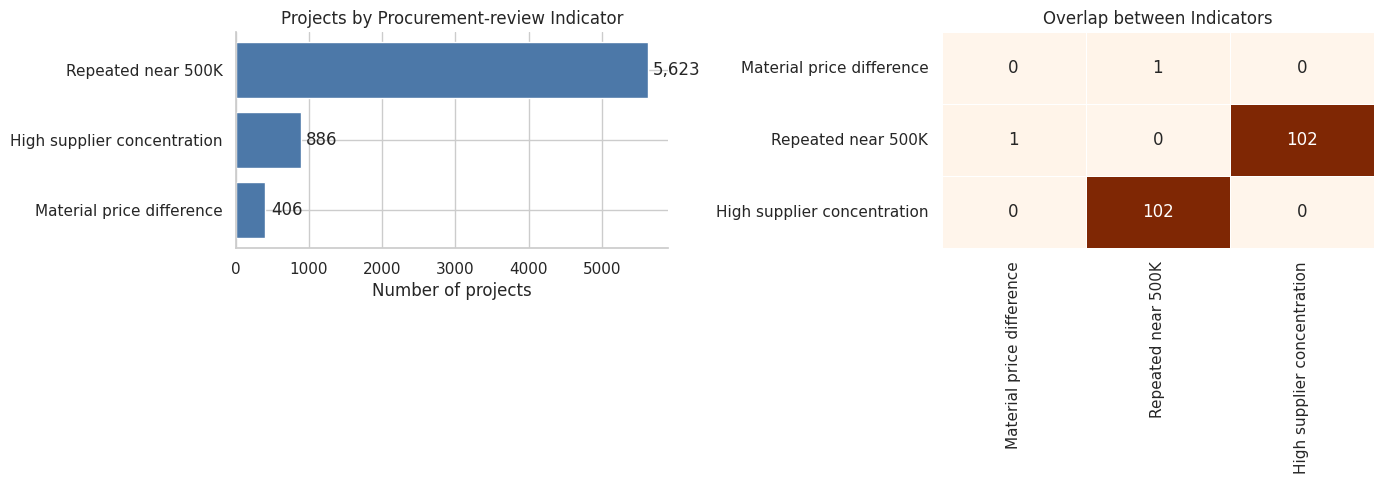

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dads5001-data-tools/project/eda/figure/fig04_01_procurement_review_indicators.png


In [50]:
# Visualize procurement-review indicators and their overlap
indicator_counts = (
    indicator_matrix
    .sum()
    .sort_values(ascending=True)
)

overlap_for_plot = indicator_overlap.copy()
np.fill_diagonal(overlap_for_plot.values, 0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

bars = axes[0].barh(
    indicator_counts.index,
    indicator_counts.values,
    color='#4C78A8'
)

axes[0].bar_label(
    bars,
    fmt='{:,.0f}',
    padding=4
)

axes[0].set_title('Projects by Procurement-review Indicator')
axes[0].set_xlabel('Number of projects')
axes[0].set_ylabel('')
axes[0].spines[['top', 'right']].set_visible(False)

sns.heatmap(
    overlap_for_plot,
    annot=True,
    fmt=',.0f',
    cmap='Oranges',
    cbar=False,
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title('Overlap between Indicators')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()

figure_path = figure_directory / 'fig04_01_procurement_review_indicators.png'
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()
print(f'Figure saved: {figure_path}')

### กรณีที่ 2: โครงการลักษณะคล้ายกัน 65 โครงการในวันเดียวกัน

กลุ่มโครงการขนาดใหญ่ที่สุดอยู่ภายใต้สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อม
จังหวัดมุกดาหาร โดยมีบริษัท บ้านบุ่ง วิศวกรรม จำกัด เป็นผู้รับจ้าง

กลุ่มนี้ประกอบด้วยโครงการขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถัง ติดตั้งถัง
ไฟเบอร์กลาส และระบบโซลาร์เซลล์จำนวน 65 โครงการ ซึ่งมีลักษณะงานใกล้เคียงกัน
แต่ดำเนินการในหมู่บ้านและตำบลที่แตกต่างกัน

ลักษณะสำคัญของกลุ่มโครงการ ได้แก่

- วันที่เกิดรายการเดียวกัน คือ 29 ธันวาคม 2568
- ผู้รับจ้างรายเดียวกัน
- งบประมาณส่วนใหญ่อยู่ที่ 498,000 บาทต่อโครงการ
- ราคาที่ตกลงส่วนใหญ่อยู่ที่ 489,900 บาทต่อโครงการ
- งบประมาณรวมประมาณ 32.37 ล้านบาท
- ราคาที่ตกลงรวมประมาณ 31.84 ล้านบาท

รูปแบบดังกล่าวพบทั้งการเกิดซ้ำของโครงการเฉพาะเจาะจงใกล้ 500,000 บาท
และการกระจุกตัวสูงของผู้รับจ้าง จึงถูกจัดอยู่ในกลุ่มที่ควรตรวจสอบเป็น
ลำดับสูง

อย่างไรก็ตาม แต่ละโครงการดำเนินการคนละพื้นที่ จึงอาจมีเหตุผลด้านสถานที่
การบริหารโครงการ หรือแผนการดำเนินงานที่ทำให้ต้องจัดซื้อแยกกัน ข้อมูลชุดนี้
ยังไม่สามารถระบุได้ว่าโครงการเหล่านี้ควรรวมการจัดซื้อเป็นครั้งเดียวหรือไม่

การตรวจสอบเพิ่มเติมควรพิจารณาแผนการจัดซื้อประจำปี ขอบเขตงาน แหล่งงบประมาณ
ผู้เสนอราคารายอื่น และเหตุผลในการแยกโครงการแต่ละพื้นที่

## 6. สรุปผลการวิเคราะห์

การวิเคราะห์โครงการจ้างก่อสร้างปีงบประมาณ 2569 จำนวน 178,978 โครงการ
พบประเด็นสำคัญดังนี้

### 6.1 คุณภาพข้อมูล

พบโครงการที่มีประเด็นด้านคุณภาพข้อมูลอย่างน้อยหนึ่งข้อจำนวน 822 โครงการ
ประกอบด้วยราคากลางที่สูญหายหรือมีสัดส่วนผิดสังเกต และโครงการที่ยอดรวม
มูลค่าสัญญาไม่สอดคล้องกับยอดรวมระดับโครงการ

กรณีโครงการที่มีสมาชิกกิจการร่วมค้าหลายแถวไม่ถูกจัดเป็นความผิดปกติ
เนื่องจากเป็นโครงสร้างข้อมูลของคู่สัญญาหลายฝ่าย

### 6.2 ส่วนต่างของราคาอย่างมีสาระสำคัญ

พบ 406 โครงการที่ราคาตกลงสูงกว่างบประมาณหรือราคากลางอย่างมีสาระสำคัญ
โดยใช้เกณฑ์ส่วนต่างมากกว่า 10,000 บาทและมากกว่า 1%

ตัวชี้วัดนี้ระบุโครงการที่ควรตรวจสอบเอกสารเพิ่มเติม แต่ไม่สามารถระบุ
สาเหตุของส่วนต่างได้จากข้อมูลชุดนี้เพียงอย่างเดียว

### 6.3 รูปแบบโครงการใกล้ 500,000 บาทที่เกิดซ้ำ

พบ 5,623 โครงการที่ใช้วิธีเฉพาะเจาะจง มีงบประมาณระหว่าง 490,000 ถึง
500,000 บาท และอยู่ในกลุ่มตั้งแต่ 3 โครงการขึ้นไปที่มีหน่วยงานย่อย
ผู้รับจ้าง และวันที่เกิดรายการเดียวกัน

โครงการกลุ่มนี้คิดเป็น 3.14% ของโครงการก่อสร้างทั้งหมด และมีงบประมาณรวม
ประมาณ 2.79 พันล้านบาท

### 6.4 การกระจุกตัวสูงของผู้รับจ้าง

พบความสัมพันธ์ระหว่างหน่วยงานย่อยกับผู้รับจ้างที่มีการกระจุกตัวสูง
จำนวน 55 ความสัมพันธ์ ครอบคลุม 886 โครงการ

แต่ละความสัมพันธ์มีผู้รับจ้างที่ได้รับอย่างน้อย 10 โครงการ และครองสัดส่วน
อย่างน้อย 75% ทั้งในด้านจำนวนโครงการและมูลค่าสัญญาของหน่วยงานย่อยนั้น

### 6.5 ลำดับความสำคัญในการตรวจสอบ

เมื่อพิจารณาตัวชี้วัดทั้ง 3 มิติร่วมกัน พบว่า

- 172,166 โครงการ หรือ 96.19% ไม่พบตัวชี้วัด
- 6,709 โครงการ หรือ 3.75% พบตัวชี้วัด 1 มิติ
- 103 โครงการ หรือ 0.06% พบตัวชี้วัด 2 มิติ
- ไม่พบโครงการที่มีตัวชี้วัดครบทั้ง 3 มิติ

ผลลัพธ์ช่วยลดขอบเขตจากโครงการเกือบ 179,000 โครงการ เหลือ 103 โครงการ
ที่ควรได้รับการตรวจสอบเป็นลำดับแรก โดยการจัดลำดับนี้เป็นเครื่องมือคัดกรอง
ไม่ใช่ข้อสรุปเกี่ยวกับการทุจริต

## 7. ข้อจำกัดของการวิเคราะห์

การตีความผลลัพธ์ต้องพิจารณาข้อจำกัดดังต่อไปนี้

1. ข้อมูลครอบคลุมเฉพาะปีงบประมาณ 2569 จึงไม่สามารถระบุได้ว่ารูปแบบที่พบ
   เป็นเหตุการณ์เฉพาะปีหรือเป็นพฤติกรรมที่เกิดขึ้นต่อเนื่อง

2. ข้อมูลแสดงเฉพาะผู้ชนะการเสนอราคา แต่ไม่มีข้อมูลผู้เสนอราคารายอื่น
   จำนวนผู้เข้าร่วมแข่งขัน ราคาที่เสนอ และเหตุผลในการคัดเลือก จึงไม่สามารถ
   ประเมินระดับการแข่งขันโดยตรง

3. โครงการวิธีเฉพาะเจาะจงไม่มีวันที่ประกาศจัดซื้อจัดจ้าง การจับกลุ่มจึงใช้
   วันที่เกิดรายการแทน ซึ่งอาจไม่ใช่วันที่ตัดสินใจจัดซื้อหรือวันที่ลงนาม
   ในสัญญา

4. การกระจุกตัวของผู้รับจ้างอาจเกิดจากความเชี่ยวชาญเฉพาะด้าน ความได้เปรียบ
   ทางภูมิศาสตร์ หรือจำนวนผู้ประกอบการในพื้นที่ที่จำกัด

5. โครงการที่มีลักษณะงานคล้ายกันแต่ดำเนินการคนละพื้นที่อาจมีเหตุผลที่เหมาะสม
   สำหรับการแยกจัดซื้อ ข้อมูลชุดนี้ไม่มีรายละเอียดเพียงพอที่จะประเมินเหตุผล
   ดังกล่าว

6. เกณฑ์ 490,000–500,000 บาทเป็นช่วงที่กำหนดจากรูปแบบการกระจุกตัวที่พบใน
   ข้อมูล การวิเคราะห์นี้ไม่ได้ใช้เกณฑ์ดังกล่าวเพื่อสรุปการปฏิบัติตามหรือ
   การฝ่าฝืนกฎหมาย

7. ความแตกต่างระหว่างงบประมาณ ราคากลาง และราคาที่ตกลงอาจเกิดจากการแก้ไข
   ขอบเขตงาน สัญญาเพิ่มเติม หรือการบันทึกข้อมูล จึงต้องตรวจสอบกับเอกสาร
   ต้นทางก่อนสรุปสาเหตุ

## 8. ข้อเสนอแนะสำหรับการนำผลไปใช้

1. ตรวจสอบเอกสารของโครงการ High priority จำนวน 103 โครงการก่อน เนื่องจาก
   พบตัวชี้วัดพร้อมกันอย่างน้อย 2 มิติ

2. ตรวจสอบกรณีที่ราคาตกลงสูงกว่างบประมาณหรือราคากลางด้วยมูลค่าสูง แม้จะพบ
   เพียงตัวชี้วัดเดียว เนื่องจากอาจมีผลกระทบทางการเงินสูง

3. ตรวจสอบแผนการจัดซื้อ ขอบเขตงาน และเหตุผลในการแยกโครงการของกลุ่มงาน
   ลักษณะคล้ายกันที่ดำเนินการโดยหน่วยงานและผู้รับจ้างรายเดียวกัน

4. ตรวจสอบข้อมูลราคากลางและมูลค่าสัญญาของโครงการที่มีปัญหาคุณภาพข้อมูล
   จำนวน 822 โครงการก่อนนำไปใช้ในการวิเคราะห์ขั้นต่อไป

5. เพิ่มข้อมูลผู้เสนอราคาทั้งหมด จำนวนผู้เข้าร่วมแข่งขัน และราคาที่เสนอ
   เพื่อให้สามารถวิเคราะห์การแข่งขันได้ละเอียดขึ้น

6. เชื่อมโยงข้อมูลหลายปีงบประมาณเพื่อศึกษาความต่อเนื่องของความสัมพันธ์
   ระหว่างหน่วยงานกับผู้รับจ้าง และตรวจสอบว่ารูปแบบที่พบเกิดซ้ำข้ามปีหรือไม่

ผลลัพธ์ทั้งหมดเป็นเครื่องมือสำหรับจัดลำดับการตรวจสอบ ไม่ใช่หลักฐานหรือ
ข้อสรุปว่ามีการทุจริต

In [51]:
# Export review outputs for later reporting
from pathlib import Path

output_directory = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/processed'
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

project_review_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    subagency_column,
    province_column,
    method_column,
    supplier_id_column,
    supplier_name_column,
    transaction_date_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'reference_price_status',
    'flag_reference_price_issue',
    'flag_entity_value_mismatch',
    'flag_multi_party_contract',
    'budget_overrun',
    'budget_overrun_pct',
    'reference_overrun',
    'reference_overrun_pct',
    'near_500k_cluster_size',
    'flag_material_price_difference',
    'flag_repeated_near_500k_pattern',
    'flag_high_supplier_concentration',
    'data_quality_indicator_count',
    'procurement_indicator_count',
    'review_priority'
]

project_review_output = project_data[
    project_review_columns
].copy()

high_priority_output = project_review_output.loc[
    project_review_output['review_priority']
    .eq('High priority')
].copy()

repeated_cluster_output = (
    near_500k_clusters.loc[
        near_500k_clusters['project_count'] >= 3
    ]
    .sort_values(
        ['project_count', 'total_budget'],
        ascending=False
    )
)

project_review_path = (
    output_directory
    / 'project_review_indicators_2569.csv'
)

high_priority_path = (
    output_directory
    / 'high_priority_projects_2569.csv'
)

repeated_cluster_path = (
    output_directory
    / 'repeated_near_500k_clusters_2569.csv'
)

supplier_concentration_path = (
    output_directory
    / 'high_supplier_concentration_2569.csv'
)

project_review_output.to_csv(
    project_review_path,
    index=False,
    encoding='utf-8-sig'
)

high_priority_output.to_csv(
    high_priority_path,
    index=False,
    encoding='utf-8-sig'
)

repeated_cluster_output.to_csv(
    repeated_cluster_path,
    index=False,
    encoding='utf-8-sig'
)

high_concentration_relationships.to_csv(
    supplier_concentration_path,
    index=False,
    encoding='utf-8-sig'
)

export_summary = pd.DataFrame({
    'file_name': [
        project_review_path.name,
        high_priority_path.name,
        repeated_cluster_path.name,
        supplier_concentration_path.name
    ],
    'rows': [
        len(project_review_output),
        len(high_priority_output),
        len(repeated_cluster_output),
        len(high_concentration_relationships)
    ],
    'file_size_mb': [
        project_review_path.stat().st_size / 1024**2,
        high_priority_path.stat().st_size / 1024**2,
        repeated_cluster_path.stat().st_size / 1024**2,
        supplier_concentration_path.stat().st_size / 1024**2
    ]
})

display(
    export_summary.style.format({
        'rows': '{:,.0f}',
        'file_size_mb': '{:,.2f}'
    })
)

,file_name,rows,file_size_mb
0,project_review_indicators_2569.csv,"178,978",158.16
1,high_priority_projects_2569.csv,103,0.12
2,repeated_near_500k_clusters_2569.csv,"1,245",0.27
3,high_supplier_concentration_2569.csv,55,0.01


## 9. ผลลัพธ์ของ Notebook

Notebook นี้แยกการคัดกรองออกเป็นสองส่วน ได้แก่

1. ตัวชี้วัดคุณภาพข้อมูล
2. ตัวชี้วัดเพื่อการตรวจสอบด้านการจัดซื้อจัดจ้าง

ตัวชี้วัดด้านการจัดซื้อจัดจ้างประกอบด้วย 3 มิติ:

- ส่วนต่างของราคาอย่างมีสาระสำคัญ
- รูปแบบโครงการเฉพาะเจาะจงใกล้ 500,000 บาทที่เกิดซ้ำ
- การกระจุกตัวสูงของผู้รับจ้างภายในหน่วยงานย่อย

จากโครงการ 178,978 โครงการ พบ 6,812 โครงการ
ที่มีตัวชี้วัดอย่างน้อย 1 มิติ ในจำนวนนี้มี 6,709 โครงการ
อยู่ในระดับ `Standard review` และ 103 โครงการ
อยู่ในระดับ `High priority`

Notebook สร้างไฟล์ผลลัพธ์หลัก 4 ไฟล์:

1. `project_review_indicators_2569.csv`  
   ตัวชี้วัดระดับโครงการทั้งหมด พร้อมเหตุผลด้านคุณภาพข้อมูล
   และลำดับความสำคัญในการตรวจสอบ

2. `high_priority_projects_2569.csv`  
   โครงการที่พบตัวชี้วัดด้านการจัดซื้ออย่างน้อย 2 มิติ

3. `repeated_near_500k_clusters_2569.csv`  
   Cluster โครงการใกล้ 500,000 บาทตั้งแต่ 3 โครงการขึ้นไป

4. `high_supplier_concentration_2569.csv`  
   ความสัมพันธ์หน่วยงานย่อย–ผู้รับจ้างที่ผ่านเกณฑ์การกระจุกตัวสูง

ผลลัพธ์ทั้งหมดเป็นการคัดกรองจากรูปแบบในข้อมูล
ไม่ใช่หลักฐานหรือข้อสรุปเกี่ยวกับการทุจริต การตรวจสอบขั้นต่อไป
ต้องใช้เอกสารต้นทาง ข้อมูลผู้เสนอราคารายอื่น และบริบทของ
แต่ละโครงการประกอบ